In [ ]:
#!pip install gstools
#!pip install georasters
# !pip install geemap
!pip install pingouin
!pip install contextily
#!pip install geopandas
#!pip install translate
!pip install -U deep-translator
from deep_translator import DeeplTranslator#ChatGptTranslator,
#from translate import Translator
#from googletrans import Translator
# Initialize the translator
#translator= Translator(provider='microsoft',to_lang='en')

from google.colab import drive
import io
import sys
from contextlib import redirect_stdout
import contextily as cx
import os
os.environ['USE_PYGEOS'] = '0'
with io.StringIO() as buf, redirect_stdout(buf):
   drive.mount('/content/drive')
   output = buf.getvalue()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.8 MB/s eta 0:00:00


In [ ]:
!pip install cartopy

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
import numpy as np
#import gstools as gs
import matplotlib.pyplot as plt
# import ee
# import geemap
import requests
from shapely.geometry import Polygon
from shapely.geometry import Point
#import tensorflow as tf
#from tensorflow import keras
#from tensorflow.keras import layers
from datetime import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import pingouin as pg
#from google.colab import drive
#drive.mount('/content/drive')
#ee.Authenticate()
#ee.Initialize(project='ee-jolejua')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 54.6 MB/s eta 0:00:00


# Alistamiento de datos para correlaciones

Se corre cuando se tiene una nueva base de datos para alistar el archivo, sólo se debe hacer una vez, y dicho archivo queda guardado, mostrandose en el siguiente bloque

<Axes: >

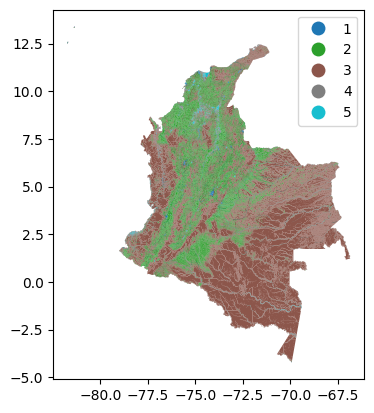

In [ ]:
dfg=gpd.read_file(r'/content/drive/Shareddrives/PIGCC/Satelite/Scripts/Cobertura_de_la_tierra_100K_Periodo_2020_limite_administrativo/shape Limite admin/e_cobertura_tierra_2020_admin.shp')#8\COBERTURAS CORINE 2018\shape coberturas 2018\cobertura_tierra_clc_2018.shp')
dfg.plot('nivel_1',legend=True)

In [ ]:
dfg.columns

Index(['OBJECTID', 'codigo', 'leyenda', 'insumo', 'apoyo', 'confiabili',
       'cambio', 'nivel_1', 'nivel_2', 'nivel_3', 'nivel_4', 'nivel_5',
       'nivel_6', 'area_ha', 'nom_dpto', 'nom_mpio', 'Cod_dane_m', 'Categoria',
       'Cod_dane_d', 'cod_aa', 'nom_aa', 'SHAPE_Leng', 'SHAPE_Area',
       'geometry'],
      dtype='object')

In [ ]:
mydict1={'1':'1, Territorios artificializados','2':'2. Territorios agrícolas','3':'3. Bosques y áreas seminaturales','4':'4. Áreas húmedas','5':'5. Superficies de agua'}
for i in mydict1.keys():
  mydict1[i]=DeeplTranslator(api_key="REDACTED_DEEPL_KEY", source="es", target="en", use_free_api=True).translate(mydict1[i])
mydict1

{'1': '1, Artificialized territories',
 '2': '2. Agricultural territories',
 '3': '3. Forests and semi-natural areas',
 '4': '4. Wet areas',
 '5': '5. Water surfaces'}

In [ ]:
np.array(list(mydict1.values()))

array(['1, Artificialized territories', '2. Agricultural territories',
       '3. Forests and semi-natural areas', '4. Wet areas',
       '5. Water surfaces'], dtype='<U33')

In [ ]:
import csv

with open('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/Nivel3.csv', mode='r') as infile:
    reader = csv.reader(infile)
    with open('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/N3.csv', mode='w') as outfile:
        writer = csv.writer(outfile)
        mydict = {rows[1]:DeeplTranslator(api_key="REDACTED_DEEPL_KEY", source="es", target="en", use_free_api=True).translate(rows[0]) for rows in reader}
#mydict = np.array([translator.translate(text, dest='es').text for text in mydict])
mydict

{'111': '1.1.1. Continuous urban fabric',
 '112': '1.1.2. Discontinuous urban fabric',
 '121': '1.2.1. Industrial or commercial zones',
 '122': '1.2.2. Road and rail network and associated lands',
 '123': '1.2.3. Port areas',
 '124': '1.2.4. Airports',
 '125': '1.2.5. Hydraulic works',
 '131': '1.3.1. Mining extraction zones',
 '132': '1.3.2. Waste disposal area',
 '141': '1.4.1. Urban Green Zones',
 '142': 'Recreational facilities',
 '211': '2.1.1. Other transitory crops',
 '212': '2.1.2. Cereals',
 '213': '2.1.3. Oilseeds and leguminous crops',
 '214': 'Vegetables',
 '215': '2.1.5. Tubers',
 '221': '2.2.1. Permanent herbaceous crops',
 '222': '2.2.2. Permanent bush crops',
 '223': '2.2.3. Permanent tree crops',
 '224': '2.2.4. Agroforestry crops',
 '225': '2.2.5. Confined crops',
 '231': '2.3.1. Clean pastures',
 '232': '2.3.2. Wooded pastures',
 '233': '2.3.3. Weededed Pastures',
 '241': '2.4.1. Crop Mosaic',
 '242': '2.4.2. Mosaic of pastures and crops',
 '243': '2.4.3. Mosaic of c

In [ ]:
dfg['Leyenda_1']=dfg['nivel_1'].map(mydict1)
dfg[['Leyenda_1','nivel_1']]

,Leyenda_1,nivel_1
0,3. Forests and semi-natural areas,3
1,3. Forests and semi-natural areas,3
2,3. Forests and semi-natural areas,3
3,3. Forests and semi-natural areas,3
4,3. Forests and semi-natural areas,3
...,...,...
393463,3. Forests and semi-natural areas,3
393464,3. Forests and semi-natural areas,3
393465,2. Agricultural territories,2
393466,2. Agricultural territories,2


In [ ]:
dfg['Leyenda_3']=dfg['nivel_3'].map(mydict)
dfg[['Leyenda_3','nivel_3']]

,Leyenda_3,nivel_3
0,3.2.1. Grassland,321
1,3.2.3. Secondary or transitional vegetation,323
2,3.1.1. Dense forest,311
3,3.2.3. Secondary or transitional vegetation,323
4,3.1.1. Dense forest,311
...,...,...
393463,3.1.1. Dense forest,311
393464,3.1.1. Dense forest,311
393465,2.3.1. Clean pastures,231
393466,2.3.1. Clean pastures,231


In [ ]:
encoded_df = pd.get_dummies(dfg, columns=["Leyenda_3"])  # Encode the "leyenda 3" column
encoded_df1 = pd.get_dummies(dfg, columns=["Leyenda_1"])  # Encode the "Leyenda 1" column
#print(encoded_df1.columns)
encoded_df=pd.concat([encoded_df,encoded_df1[encoded_df1.columns[-5:]]], axis=1)
encoded_df['groupb']=0
encoded_df

,OBJECTID,codigo,leyenda,insumo,apoyo,confiabili,cambio,nivel_1,nivel_2,nivel_3,...,Leyenda_3_5.2.2. Seas and oceans,Leyenda_3_5.2.3. Ponds for marine aquaculture,Leyenda_3_Recreational facilities,Leyenda_3_Vegetables,"Leyenda_1_1, Artificialized territories",Leyenda_1_2. Agricultural territories,Leyenda_1_3. Forests and semi-natural areas,Leyenda_1_4. Wet areas,Leyenda_1_5. Water surfaces,groupb
0,1.0,321122,3.2.1.1.2.2. Herbazal denso inundable arbolado,Landsat_2020_mediana_07042021,None,SI,2,3,32,321,...,False,False,False,False,False,False,True,False,False,0
1,2.0,3232,3.2.3.2. Vegetación secundaria baja,Landsat_2020_mediana_07042021,None,SI,2,3,32,323,...,False,False,False,False,False,False,True,False,False,0
2,3.0,31111,3.1.1.1.1. Bosque denso alto de tierra firme,Landsat_2020_mediana_07042021,None,SI,2,3,31,311,...,False,False,False,False,False,False,True,False,False,0
3,4.0,3231,3.2.3.1. Vegetación secundaria alta,Landsat_2020_mediana_07042021,None,SI,2,3,32,323,...,False,False,False,False,False,False,True,False,False,0
4,5.0,31111,3.1.1.1.1. Bosque denso alto de tierra firme,Landsat_2020_mediana_07042021,None,SI,2,3,31,311,...,False,False,False,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393463,393464.0,31112,3.1.1.1.2. Bosque denso alto inundable,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,1,3,31,311,...,False,False,False,False,False,False,True,False,False,0
393464,393465.0,31112,3.1.1.1.2. Bosque denso alto inundable,"Landsat_2020_mediana_07042021, Landsat8_1159_0...",None,SI,1,3,31,311,...,False,False,False,False,False,False,True,False,False,0
393465,393466.0,231,2.3.1. Pastos limpios,Landsat_2020_Mediana_07042021,GoogleEarth,SI,2,2,23,231,...,False,False,False,False,False,True,False,False,False,0
393466,393467.0,231,2.3.1. Pastos limpios,Landsat_2020_Mediana_07042021,GoogleEarth,SI,2,2,23,231,...,False,False,False,False,False,True,False,False,False,0


In [ ]:
encoded_df1.columns[-5:]

Index(['Leyenda_1_1, Artificialized territories',
       'Leyenda_1_2. Agricultural territories',
       'Leyenda_1_3. Forests and semi-natural areas', 'Leyenda_1_4. Wet areas',
       'Leyenda_1_5. Water surfaces'],
      dtype='object')

<Axes: xlabel='longitude', ylabel='latitude'>

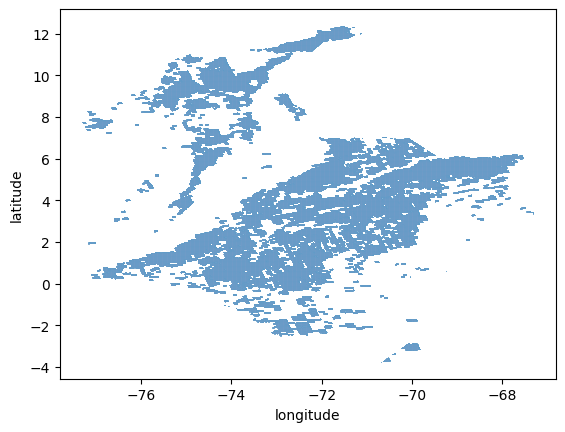

In [ ]:
df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/colombia_prom_2020_filtered.csv')
sns.scatterplot(data=df_s,x='longitude',y='latitude',s=0.5)#,hue='CH4_column_volume_mixing_ratio_dry_air_bias_corrected')

In [ ]:
#df_s.groupby(['latitude','longitude']).mean('CH4_column_volume_mixing_ratio_dry_air_bias_corrected').to_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom.csv')

In [ ]:
df_s

,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-77.305,7.745,1.606068e+12,1866.559650
1,-77.305,7.755,1.606068e+12,1866.559615
2,-77.295,7.705,1.606068e+12,1866.559567
3,-77.295,7.715,1.606068e+12,1866.559602
4,-77.295,7.725,1.606068e+12,1866.559608
...,...,...,...,...
307150,-67.325,3.455,1.577987e+12,1835.456421
307151,-67.315,3.375,1.580923e+12,1851.070163
307152,-67.315,3.385,1.580923e+12,1851.070189
307153,-67.315,3.435,1.577987e+12,1835.456439


In [ ]:
df_s['coordinate_x']=df_s['longitude'].apply(lambda x: [x])
df_s['coordinate_y']=df_s['latitude'].apply(lambda x: [x])
df_s['coordinates']=df_s['coordinate_x']+df_s['coordinate_y']
df_s

,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates
0,-77.305,7.745,1.606068e+12,1866.559650,[-77.305],[7.745],"[-77.305, 7.745]"
1,-77.305,7.755,1.606068e+12,1866.559615,[-77.305],[7.755],"[-77.305, 7.755]"
2,-77.295,7.705,1.606068e+12,1866.559567,[-77.295],[7.705],"[-77.295, 7.705]"
3,-77.295,7.715,1.606068e+12,1866.559602,[-77.295],[7.715],"[-77.295, 7.715]"
4,-77.295,7.725,1.606068e+12,1866.559608,[-77.295],[7.725],"[-77.295, 7.725]"
...,...,...,...,...,...,...,...
307150,-67.325,3.455,1.577987e+12,1835.456421,[-67.325],[3.455],"[-67.325, 3.455]"
307151,-67.315,3.375,1.580923e+12,1851.070163,[-67.315],[3.375],"[-67.315, 3.375]"
307152,-67.315,3.385,1.580923e+12,1851.070189,[-67.315],[3.385],"[-67.315, 3.385]"
307153,-67.315,3.435,1.577987e+12,1835.456439,[-67.315],[3.435],"[-67.315, 3.435]"


In [ ]:
delta_y=0.01
delta_x=0.01
df_s['geometry'] = df_s['coordinates'].apply(
    lambda x: Polygon([
        (x[0] - delta_x, x[1] - delta_y),
        (x[0] - delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] - delta_y)
    ]))# Corregir el delta

In [ ]:
l_in=list(encoded_df.columns)
while not l_in[0]=='Leyenda_3_1.1.1. Tejido urbano continuo':
    l_in.pop(0)#(list(dfg.columns))
l_in.remove('groupb')
for i in l_in:
    encoded_df[i]=encoded_df[i]*encoded_df['SHAPE_Area']
df_s.loc[:,l_in]=None
df_s['Leyenda_1_4. Áreas húmedas'][0]

In [ ]:
for j in df_s.index:
    #print(j)
    f=encoded_df[df_s['geometry'][j].intersects(encoded_df['geometry'])]
    f1=f.groupby('groupb')[l_in].aggregate('sum') # Se suma el área total intersectada
    if not len(f1)==0:
        #print(j)
        for i in l_in:
            df_s.loc[j, i]=f1[i].iloc[0].copy()

KeyboardInterrupt: 

In [ ]:
df_s

,latitude,longitude,time,CH4_column_volume_mixing_ratio_dry_air,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,-4.165,-69.995,1.693677e+12,1909.928716,[-69.995],[-4.165],"[-69.995, -4.165]","POLYGON ((-70.00500000000001 -4.175, -70.00500...",None,None,...,None,None,None,None,None,None,None,None,None,None
1,-4.155,-70.005,1.693677e+12,1909.928711,[-70.005],[-4.155],"[-70.005, -4.155]","POLYGON ((-70.015 -4.165, -70.015 -4.145000000...",None,None,...,None,None,None,None,None,None,None,None,None,None
2,-4.145,-70.015,1.708235e+12,1880.866934,[-70.015],[-4.1450000000000005],"[-70.015, -4.1450000000000005]","POLYGON ((-70.025 -4.155, -70.025 -4.135000000...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000212
3,-4.145,-70.005,1.708235e+12,1880.867002,[-70.005],[-4.1450000000000005],"[-70.005, -4.1450000000000005]","POLYGON ((-70.015 -4.155, -70.015 -4.135000000...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000212
4,-4.145,-69.995,1.722793e+12,1851.805167,[-69.995],[-4.1450000000000005],"[-69.995, -4.1450000000000005]","POLYGON ((-70.00500000000001 -4.155, -70.00500...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601972,12.445,-71.655,1.704000e+12,1934.657396,[-71.655],[12.445],"[-71.655, 12.445]","POLYGON ((-71.665 12.435, -71.665 12.455, -71....",0.0,0.0,...,0.0,0.0,0.000426,0.000601,0.0,0.0,0.0,0.0,0.000208,0.001027
601973,12.445,-71.645,1.704233e+12,1935.313772,[-71.645],[12.445],"[-71.645, 12.445]","POLYGON ((-71.655 12.435, -71.655 12.455, -71....",0.0,0.0,...,0.0,0.0,0.000426,0.000601,0.0,0.0,0.0,0.0,0.000208,0.001027
601974,12.445,-71.635,1.703882e+12,1934.936248,[-71.635],[12.445],"[-71.635, 12.445]","POLYGON ((-71.64500000000001 12.435, -71.64500...",0.0,0.0,...,0.0,0.0,0.0,0.000601,0.0,0.0,0.0,0.0,0.000208,0.000601
601975,12.455,-71.675,1.704120e+12,1930.317069,[-71.675],[12.455],"[-71.675, 12.455]","POLYGON ((-71.685 12.445, -71.685 12.465, -71....",0.0,0.0,...,0.0,0.0,0.0,0.000601,0.0,0.0,0.0,0.0,0.000061,0.000601


In [ ]:
#Eliminar zonas de agua para evitar glint

In [ ]:
df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/corr_land_2020.csv')

#df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/glint_intersect.csv')

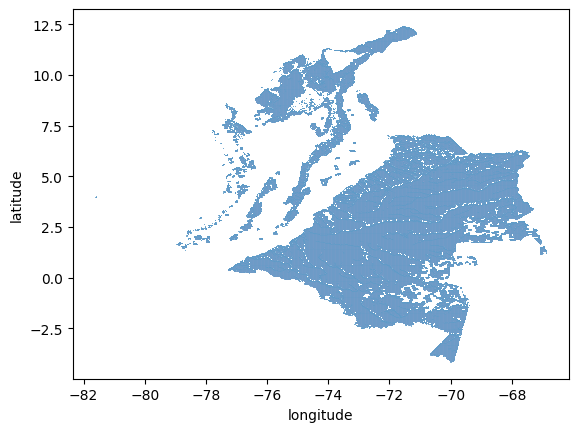

,coordinates
0,"[-69.995, -4.165]"
1,"[-70.005, -4.155]"
12,"[-69.965, -4.135]"
13,"[-69.955, -4.135]"
14,"[-69.94500000000001, -4.135]"
...,...
601920,"[-71.58500000000001, 12.415]"
601921,"[-71.575, 12.415]"
601940,"[-71.605, 12.425]"
601941,"[-71.595, 12.425]"


# Análisis de correlaciones

In [ ]:
df_corr=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/corr_land_2020_old.csv',index_col=0)
df_corr[(~(df_corr['Leyenda_1_5. Superficies de agua']>0))*(~(df_corr['Leyenda_1_4. Áreas húmedas']>0))]#+

,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,Leyenda_3_1.2.1. Zonas industriales o comerciales,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,-77.309013,7.743478,1866.559633,[-77.30901335132603],[7.7434777491102755],"[-77.30901335132603, 7.7434777491102755]",POLYGON ((-77.34494635132603 7.707544749110275...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.001214,0.288801,0.0,0.0
1,-77.273081,7.707545,1866.559612,[-77.27308073996124],[7.707545137745495],"[-77.27308073996124, 7.707545137745495]",POLYGON ((-77.30901373996124 7.671612137745495...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.002290,0.293556,0.0,0.0
2,-77.273081,7.743478,1866.559570,[-77.27308073996124],[7.7434777491102755],"[-77.27308073996124, 7.7434777491102755]",POLYGON ((-77.30901373996124 7.707544749110275...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.001139,0.292049,0.0,0.0
3,-77.273081,7.779410,1866.559604,[-77.27308073996124],[7.779410360475056],"[-77.27308073996124, 7.779410360475056]",POLYGON ((-77.30901373996124 7.743477360475056...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.000213,0.288675,0.0,0.0
6,-77.237148,7.743478,1866.559606,[-77.23714812859646],[7.7434777491102755],"[-77.23714812859646, 7.7434777491102755]",POLYGON ((-77.27308112859646 7.707544749110275...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000204,0.293148,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25565,-67.535343,3.683093,1871.177431,[-67.53534306010563],[3.6830926648900384],"[-67.53534306010563, 3.6830926648900384]",POLYGON ((-67.57127606010563 3.647159664890038...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000212,0.029261,0.0,0.0
25566,-67.535343,6.018712,1876.836449,[-67.53534306010563],[6.018712403600794],"[-67.53534306010563, 6.018712403600794]",POLYGON ((-67.57127606010563 5.982779403600794...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.019897,0.0,0.0
25567,-67.499410,3.647160,1871.177410,[-67.49941044874085],[3.6471600535252575],"[-67.49941044874085, 3.6471600535252575]",POLYGON ((-67.53534344874085 3.611227053525257...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000081,0.025519,0.0,0.0
25568,-67.463478,3.467497,1835.456441,[-67.46347783737606],[3.467496996701353],"[-67.46347783737606, 3.467496996701353]",POLYGON ((-67.49941083737606 3.431563996701353...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000032,0.020053,0.0,0.0


,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,Leyenda_3_1.2.1. Zonas industriales o comerciales,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,-77.309013,7.743478,1866.559633,[-77.30901335132603],[7.7434777491102755],"[-77.30901335132603, 7.7434777491102755]",POLYGON ((-77.34494635132603 7.707544749110275...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.001214,0.288801,0.0,0.0
1,-77.273081,7.707545,1866.559612,[-77.27308073996124],[7.707545137745495],"[-77.27308073996124, 7.707545137745495]",POLYGON ((-77.30901373996124 7.671612137745495...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.002290,0.293556,0.0,0.0
2,-77.273081,7.743478,1866.559570,[-77.27308073996124],[7.7434777491102755],"[-77.27308073996124, 7.7434777491102755]",POLYGON ((-77.30901373996124 7.707544749110275...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.001139,0.292049,0.0,0.0
3,-77.273081,7.779410,1866.559604,[-77.27308073996124],[7.779410360475056],"[-77.27308073996124, 7.779410360475056]",POLYGON ((-77.30901373996124 7.743477360475056...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.000213,0.288675,0.0,0.0
6,-77.237148,7.743478,1866.559606,[-77.23714812859646],[7.7434777491102755],"[-77.23714812859646, 7.7434777491102755]",POLYGON ((-77.27308112859646 7.707544749110275...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000204,0.293148,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25565,-67.535343,3.683093,1871.177431,[-67.53534306010563],[3.6830926648900384],"[-67.53534306010563, 3.6830926648900384]",POLYGON ((-67.57127606010563 3.647159664890038...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000212,0.029261,0.0,0.0
25566,-67.535343,6.018712,1876.836449,[-67.53534306010563],[6.018712403600794],"[-67.53534306010563, 6.018712403600794]",POLYGON ((-67.57127606010563 5.982779403600794...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.019897,0.0,0.0
25567,-67.499410,3.647160,1871.177410,[-67.49941044874085],[3.6471600535252575],"[-67.49941044874085, 3.6471600535252575]",POLYGON ((-67.53534344874085 3.611227053525257...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000081,0.025519,0.0,0.0
25568,-67.463478,3.467497,1835.456441,[-67.46347783737606],[3.467496996701353],"[-67.46347783737606, 3.467496996701353]",POLYGON ((-67.49941083737606 3.431563996701353...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000032,0.020053,0.0,0.0


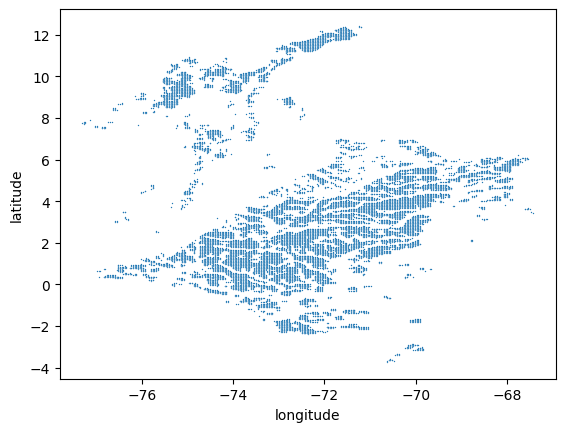

In [ ]:
df_corr=df_corr[(~(df_corr['Leyenda_1_5. Superficies de agua']>0))*(~(df_corr['Leyenda_1_4. Áreas húmedas']>0))]
sns.scatterplot(data=df_corr,x='longitude',y='latitude',s=1)
df_corr

In [ ]:
l_in=list(df_corr.columns)
#l_in.remove(['longitude', 'latitude','CH4_column_volume_mixing_ratio_dry_air_bias_corrected', 'coordinate_x','coordinate_y', 'coordinates', 'geometry'])
while not l_in[0]=='Leyenda_3_1.1.1. Tejido urbano continuo':
    l_in.pop(0)#(list(dfg.columns))
l_in

['Leyenda_3_1.1.1. Tejido urbano continuo',
 'Leyenda_3_1.1.2. Tejido urbano discontinuo',
 'Leyenda_3_1.2.1. Zonas industriales o comerciales',
 'Leyenda_3_1.2.2. Red vial, ferroviaria y terrenos asociados',
 'Leyenda_3_1.2.3. Zonas portuarias',
 'Leyenda_3_1.2.4. Aeropuertos',
 'Leyenda_3_1.2.5. Obras hidráulicas',
 'Leyenda_3_1.3.1. Zonas de extracción minera',
 'Leyenda_3_1.3.2. Zona de disposición de residuos',
 'Leyenda_3_1.4.1. Zonas verdes urbanas',
 'Leyenda_3_1.4.2. Instalaciones recreativas',
 'Leyenda_3_2.1.1. Otros cultivos transitorios',
 'Leyenda_3_2.1.2. Cereales',
 'Leyenda_3_2.1.3. Oleaginosas y leguminosas',
 'Leyenda_3_2.1.4. Hortalizas',
 'Leyenda_3_2.1.5. Tubérculos',
 'Leyenda_3_2.2.1. Cultivos permanentes herbáceos',
 'Leyenda_3_2.2.2. Cultivos permanentes arbustivos',
 'Leyenda_3_2.2.3. Cultivos permanentes arbóreos',
 'Leyenda_3_2.2.4. Cultivos agroforestales',
 'Leyenda_3_2.2.5. Cultivos confinados',
 'Leyenda_3_2.3.1. Pastos limpios',
 'Leyenda_3_2.3.2. Past

In [ ]:
correlaciones=df_corr.corr(numeric_only=True)['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
correlaciones

,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
longitude,-0.167609
latitude,0.467819
CH4_column_volume_mixing_ratio_dry_air_bias_corrected,1.000000
Leyenda_3_1.1.1. Tejido urbano continuo,0.053854
Leyenda_3_1.1.2. Tejido urbano discontinuo,0.080836
...,...
Leyenda_1_1. Territorios artificializados,0.079865
Leyenda_1_2. Territorios agrícolas,0.195299
Leyenda_1_3. Bosques y áreas seminaturales,-0.504060
Leyenda_1_4. Áreas húmedas,NaN


In [ ]:
print(len(correlaciones))
correlaciones.sort_values(ascending=False).head(10)


63


,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
CH4_column_volume_mixing_ratio_dry_air_bias_corrected,1.000000
latitude,0.467819
Leyenda_3_2.4.4. Mosaico de pastos con espacios naturales,0.301007
Leyenda_3_2.3.3. Pastos enmalezados,0.296781
Leyenda_3_3.1.4. Bosque de galería y ripario,0.238221
Leyenda_1_2. Territorios agrícolas,0.195299
Leyenda_3_3.2.1. Herbazal,0.191339
Leyenda_3_2.3.1. Pastos limpios,0.183081
Leyenda_3_2.3.2. Pastos arbolados,0.173860
Leyenda_3_2.4.2. Mosaico de pastos y cultivos,0.173597


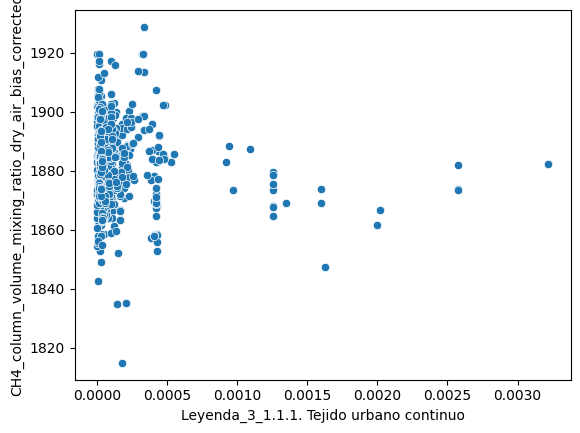

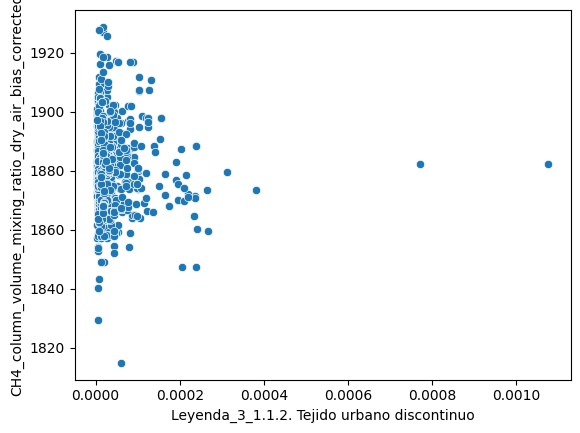

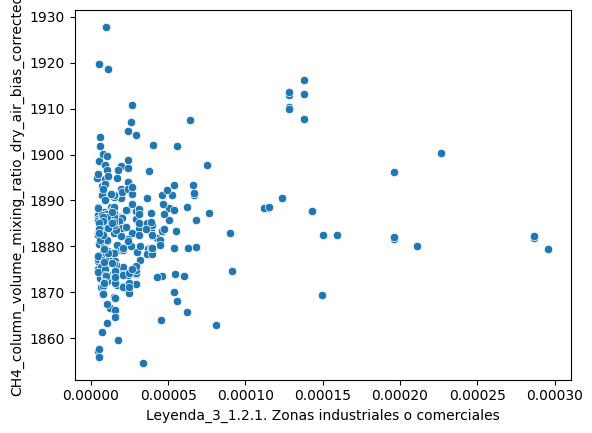

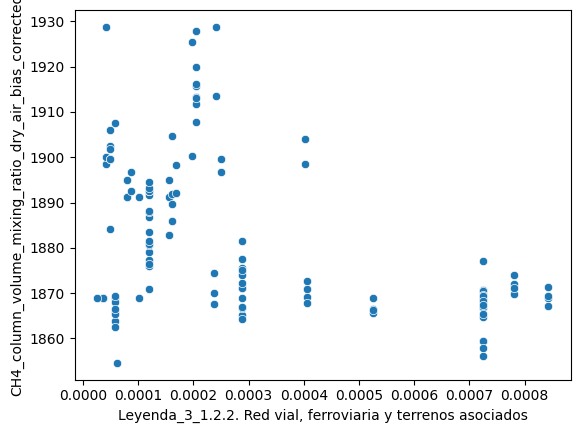

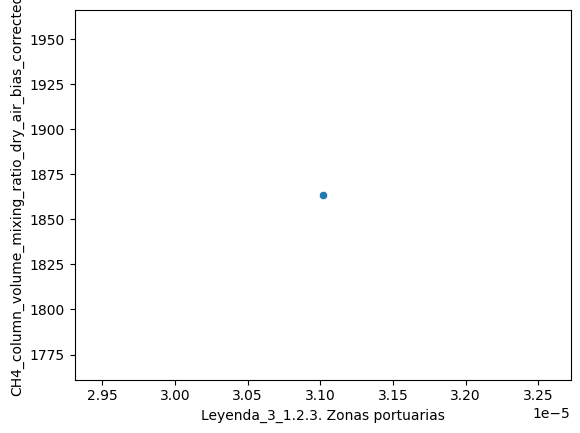

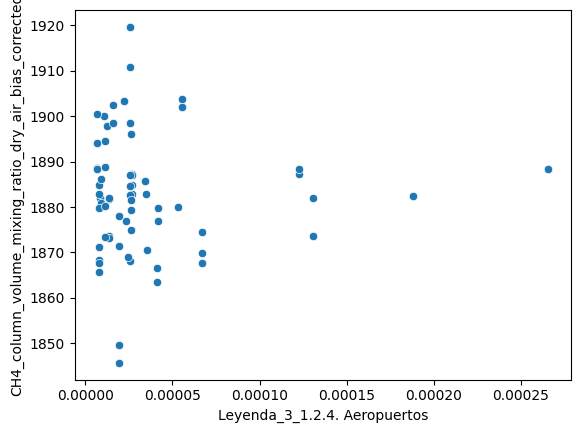

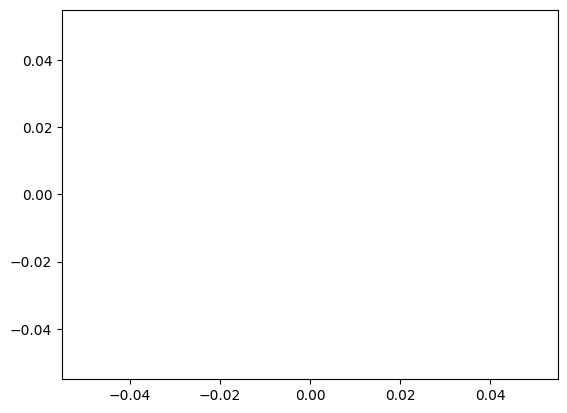

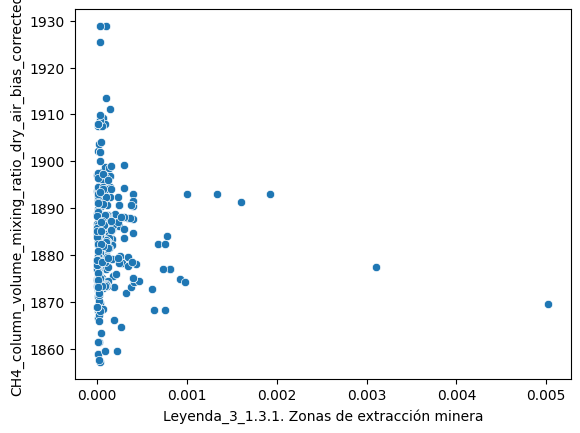

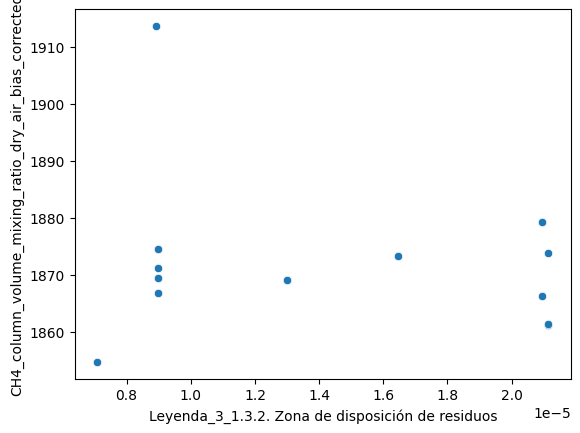

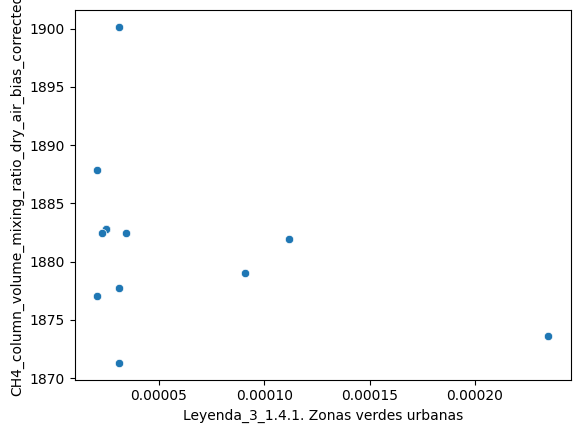

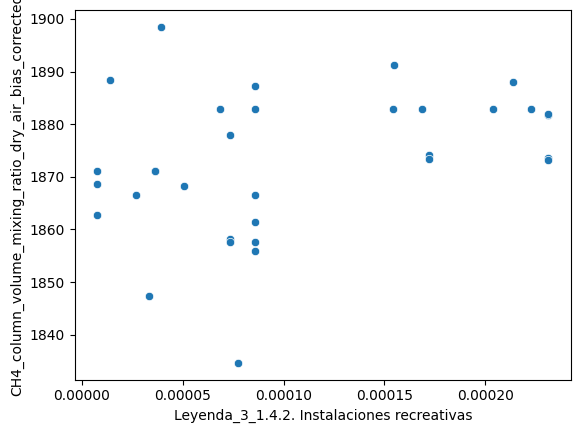

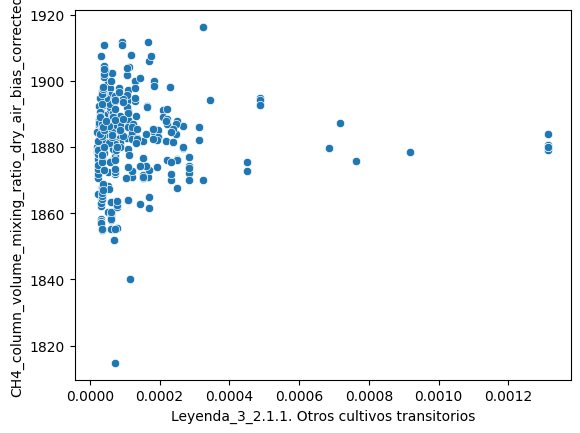

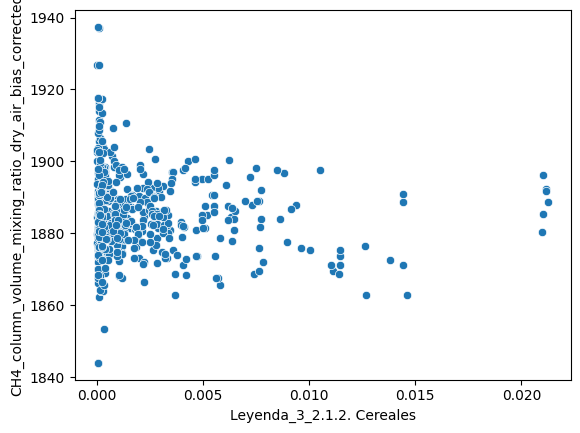

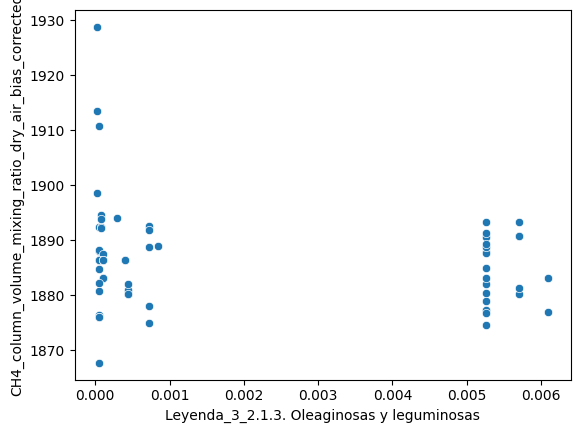

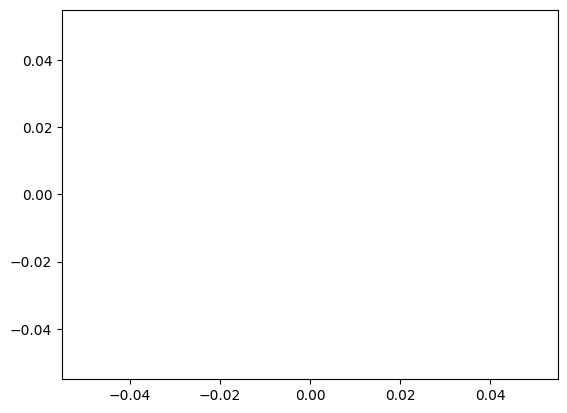

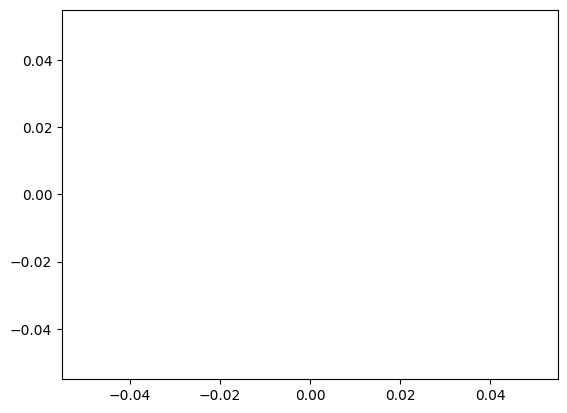

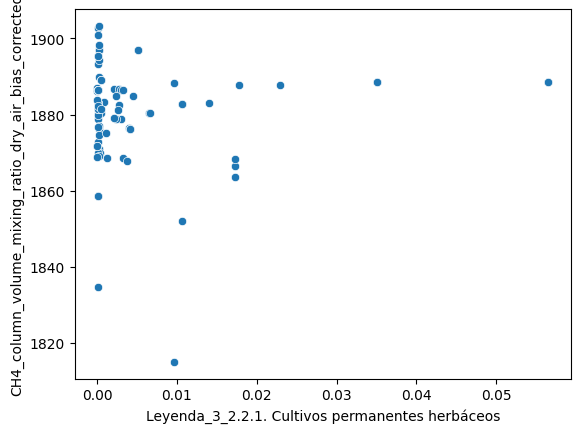

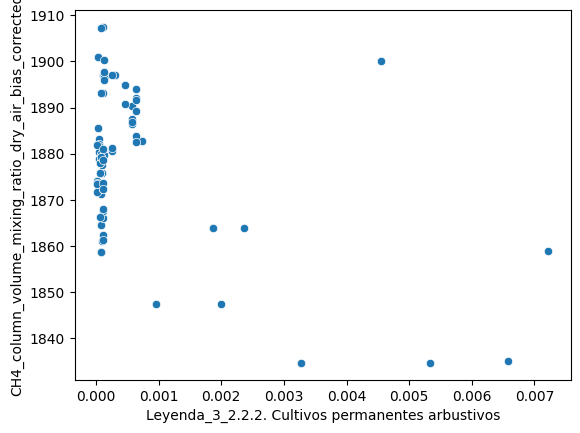

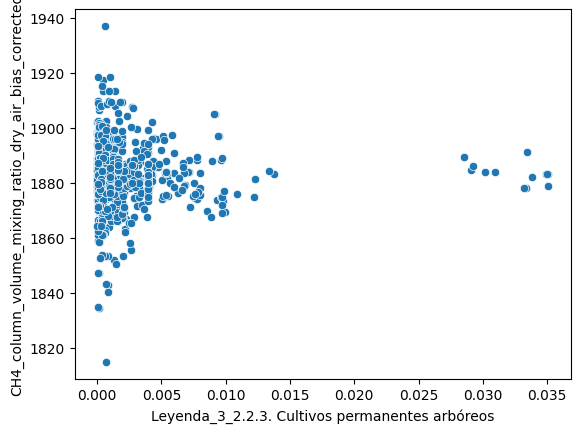

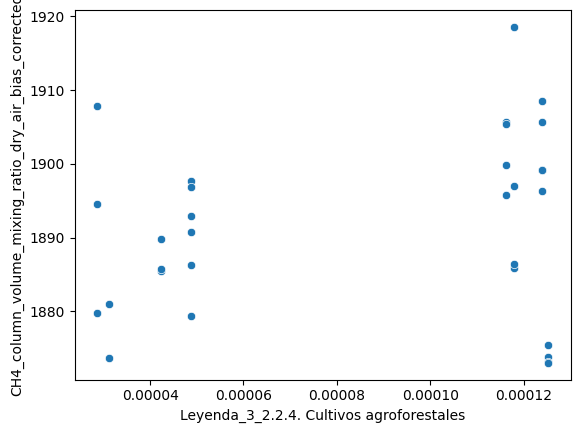

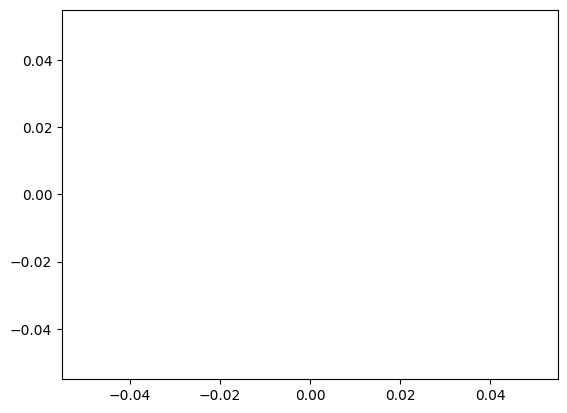

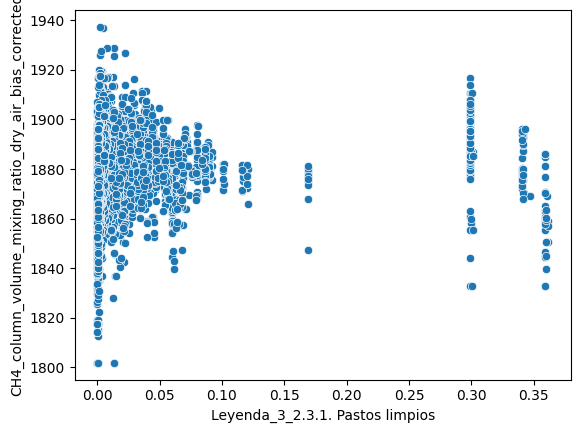

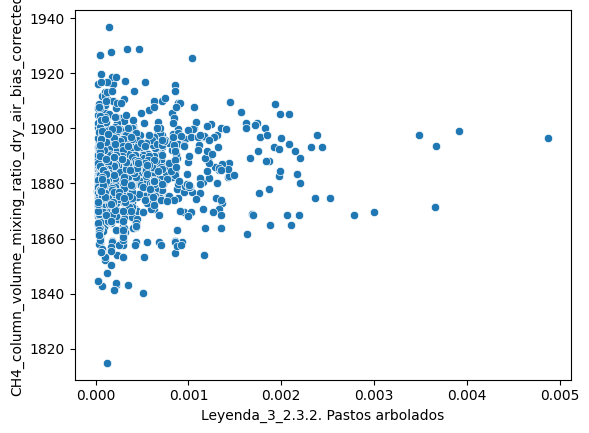

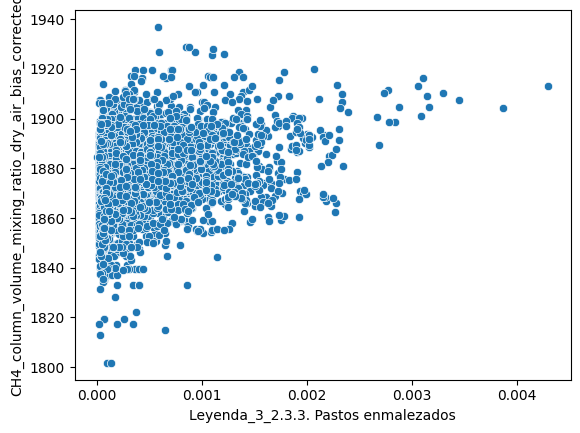

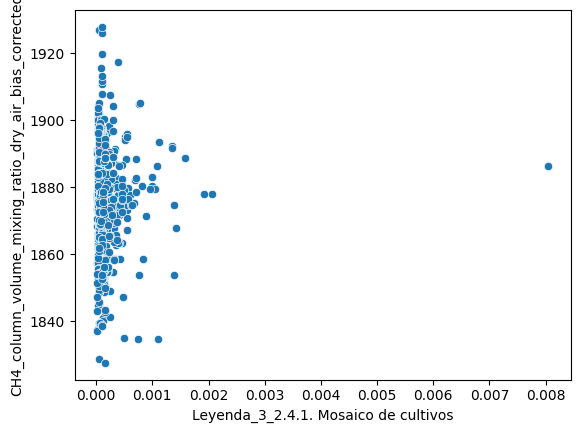

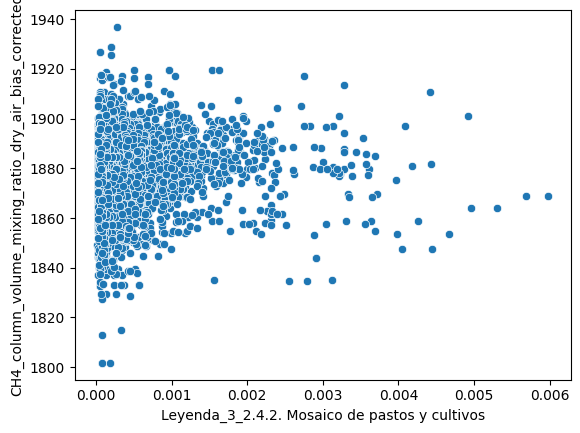

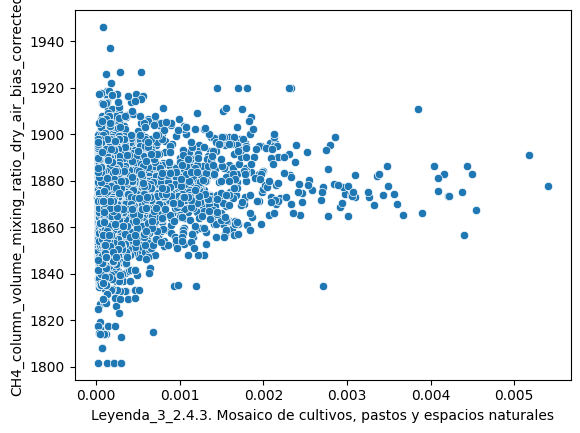

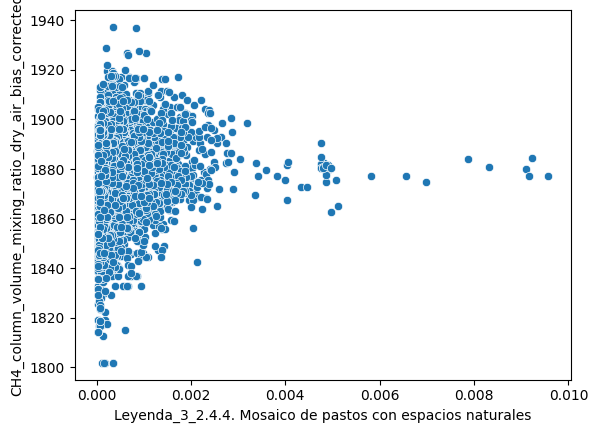

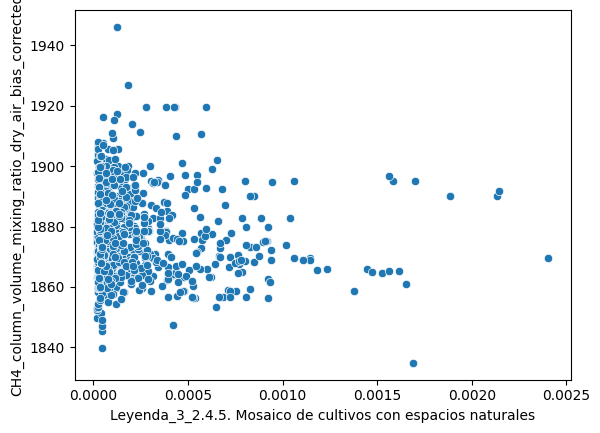

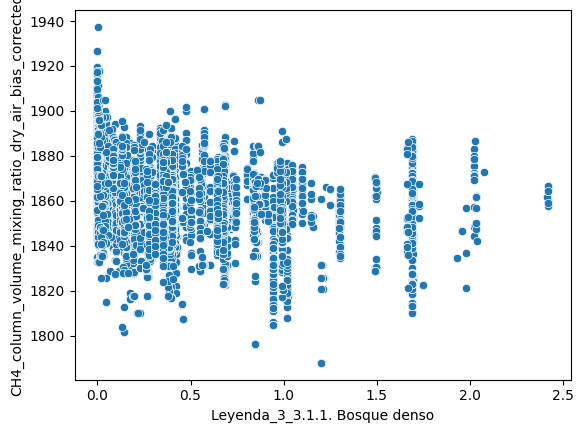

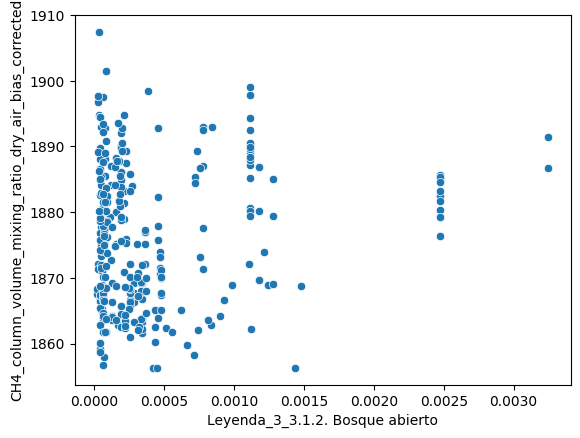

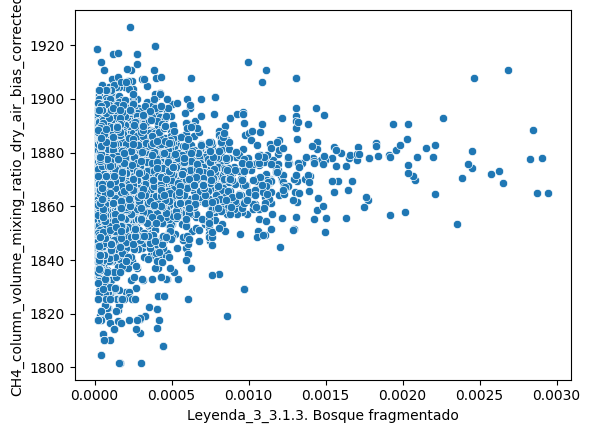

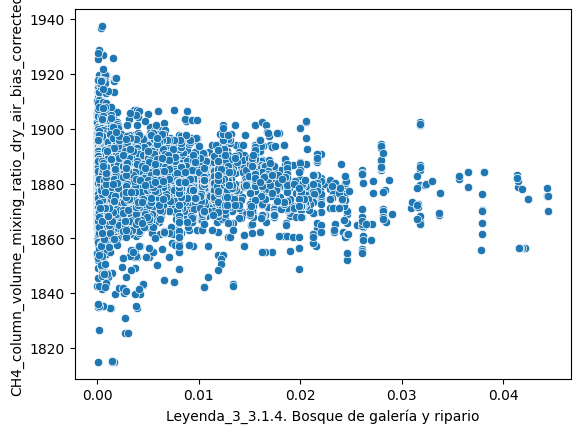

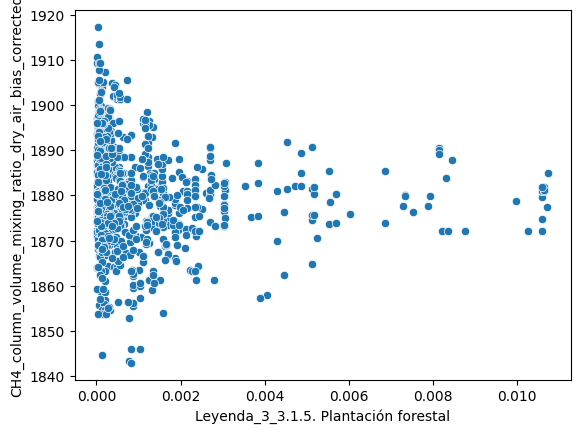

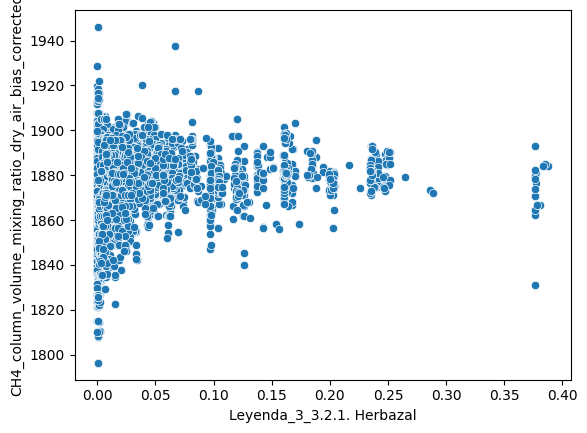

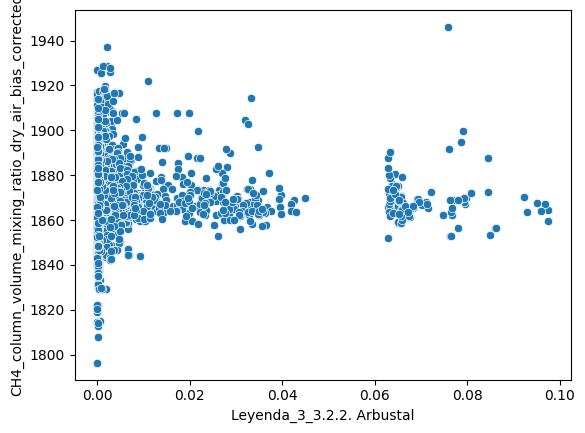

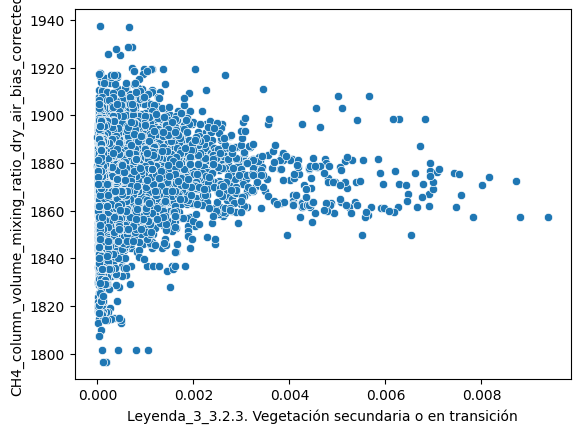

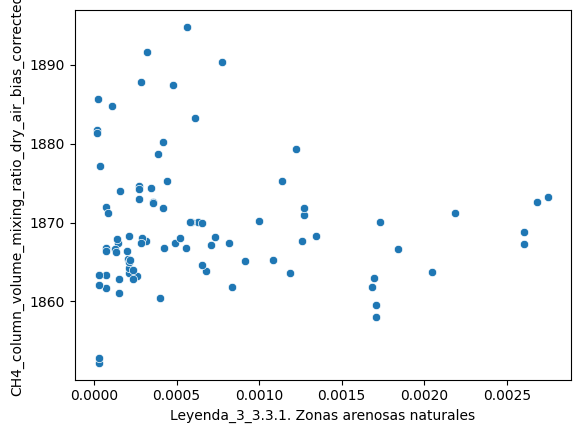

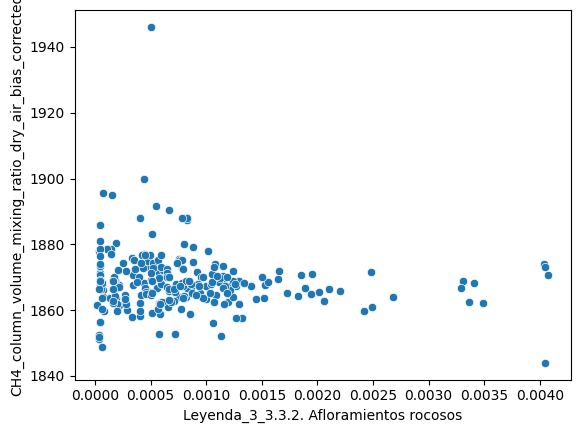

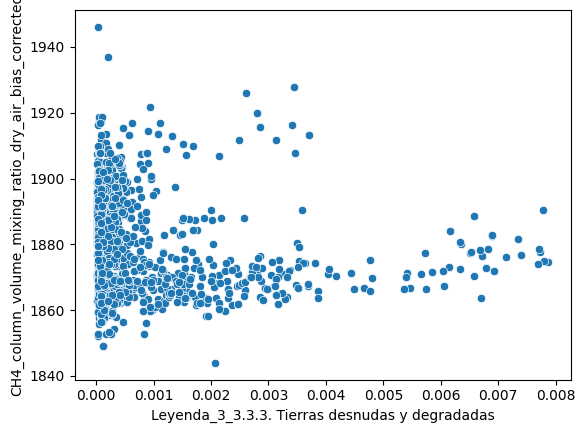

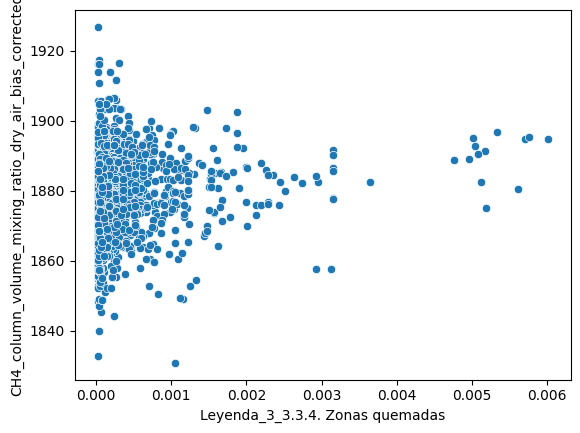

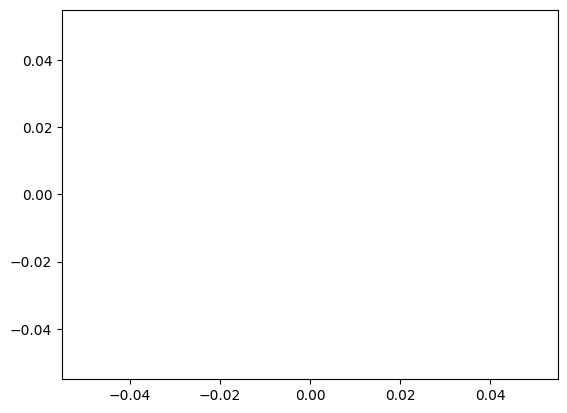

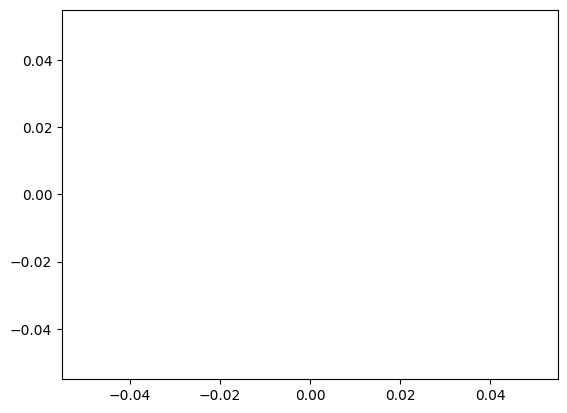

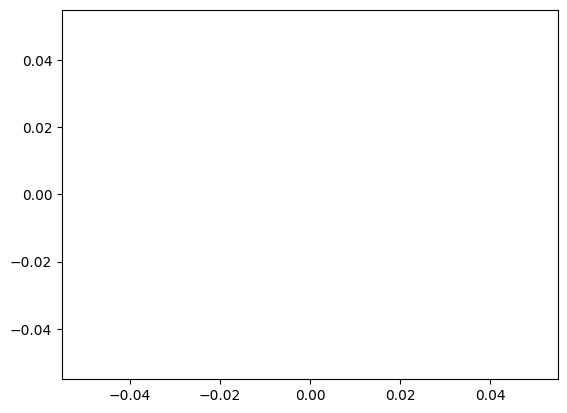

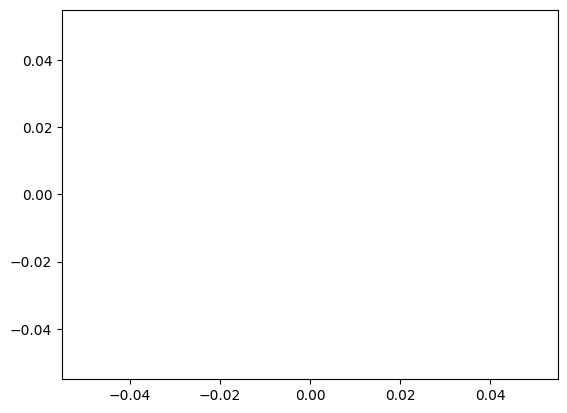

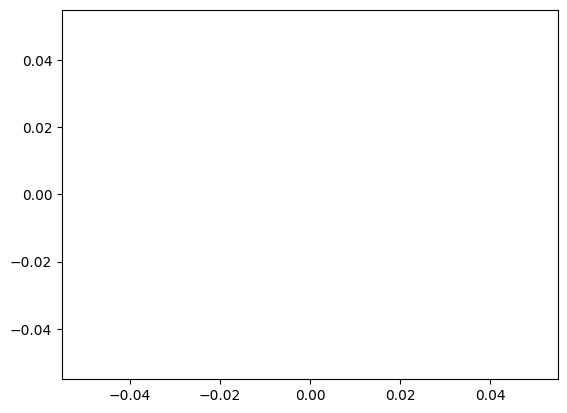

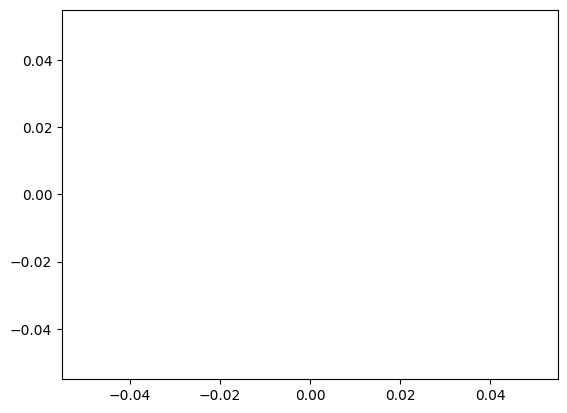

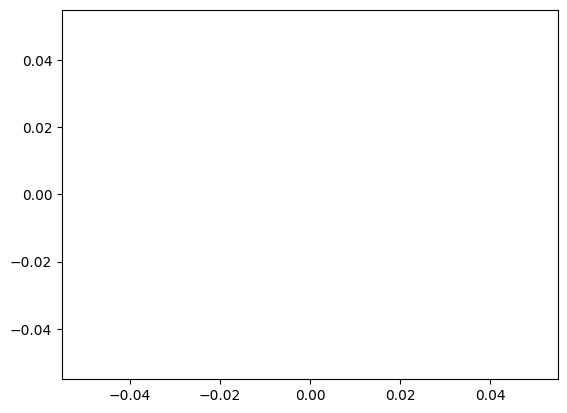

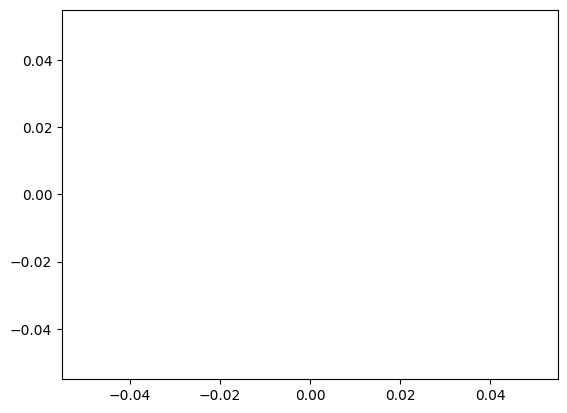

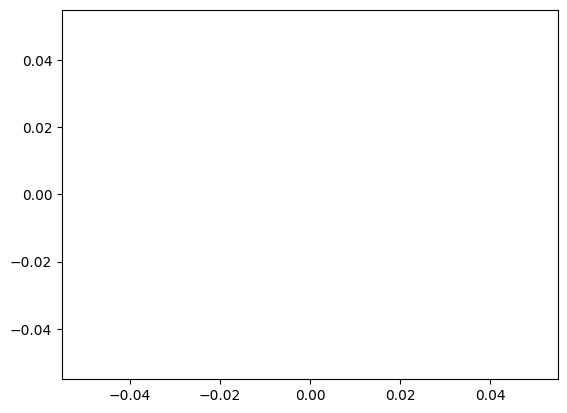

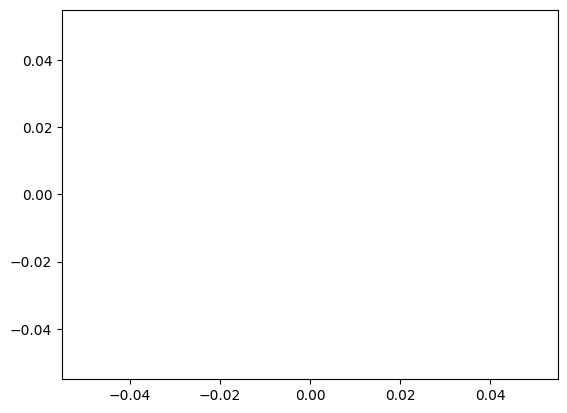

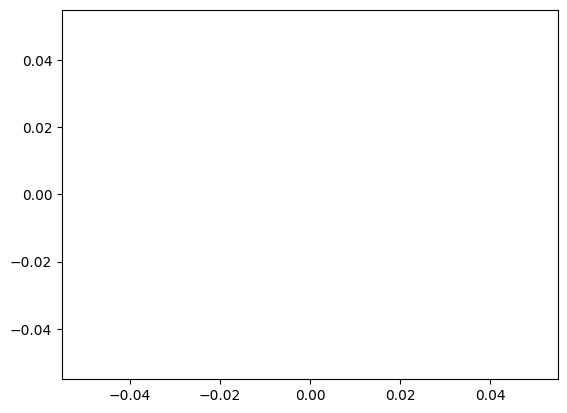

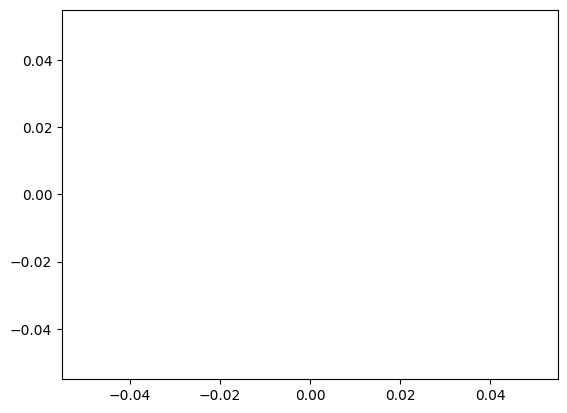

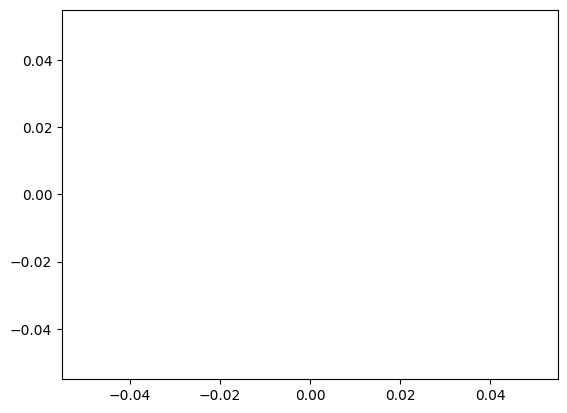

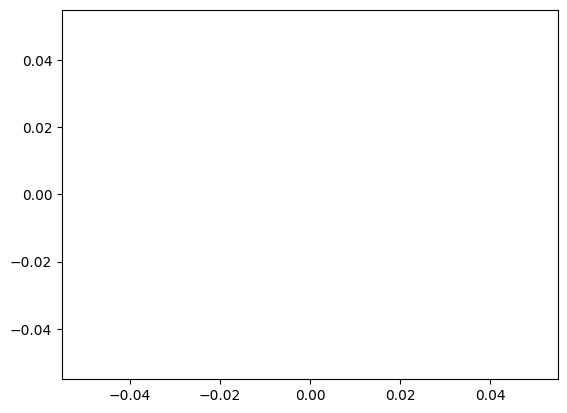

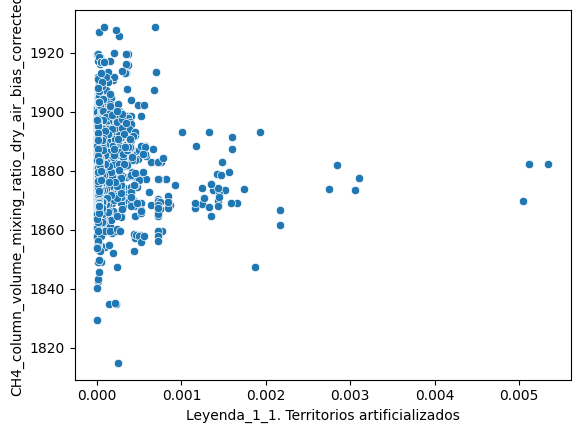

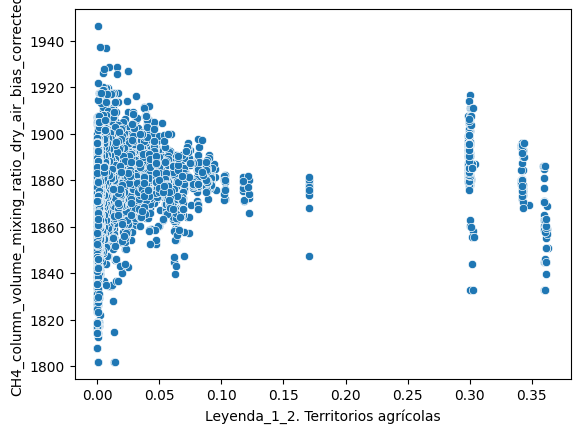

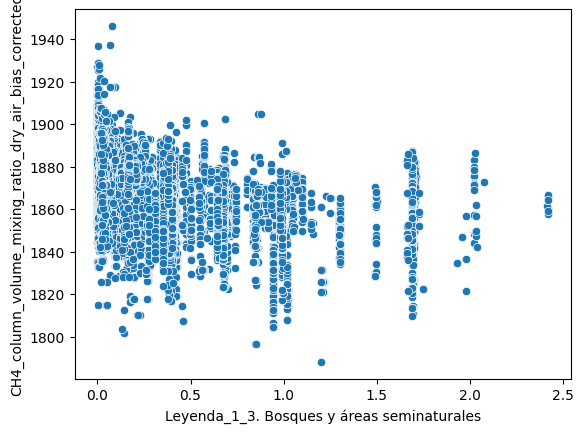

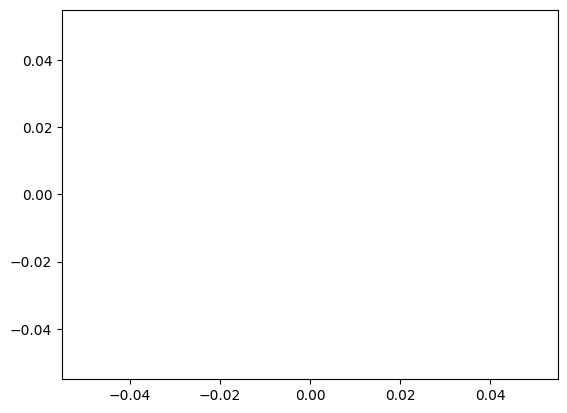

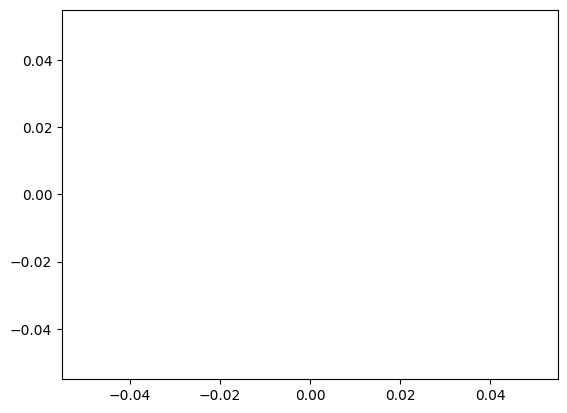

In [ ]:
d={}
for i in l_in:
    #df_filtered = df_corr[df_corr[i] >1e-15]
    df_corr.loc[df_corr[i] ==0, i] = np.nan
    #transformed, lambda_ = stats.boxcox(df_corr[i])
    #cor=df_filtered['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].corr(df_filtered[i])
    #d[i]=cor
    sns.scatterplot(x=i,y='CH4_column_volume_mixing_ratio_dry_air_bias_corrected',data=df_corr)
    plt.show()

In [ ]:
corr_final=pg.pairwise_corr(df_corr,columns=[['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'],l_in])
corr_final.sort_values(by=['p-unc'])[['X', 'Y', 'n', 'r', 'p-unc','BF10']].head(60)

,X,Y,n,r,p-unc,BF10
38,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,13764,-0.503903,0.000000e+00,inf
24,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,9674,-0.429807,0.000000e+00,inf
18,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.3. Pastos enmalezados,4246,0.250185,1.318989e-61,6.668e+57
37,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_2. Territorios agrícolas,8165,0.134572,2.627021e-34,3.38e+30
29,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.2.1. Herbazal,5123,0.163864,3.652761e-32,3.152e+28
22,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.4.4. Mosaico de pastos con espacio...,6531,0.144601,7.454791e-32,1.381e+28
16,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.1. Pastos limpios,6894,0.108574,1.567000e-19,8.327e+15
31,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.2.3. Vegetación secundaria o en tr...,6308,0.091624,3.078128e-13,5.475e+09
27,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.4. Bosque de galería y ripario,5615,-0.093639,2.056707e-12,8.993e+08
34,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.3.3. Tierras desnudas y degradadas,1127,-0.202272,7.187647e-12,5.742e+08


In [ ]:
df_sorted = corr_final.reindex(corr_final['r'].abs().sort_values(ascending=False).index)
df_sorted#[(df_sorted['p-unc']<0.01)*(df_sorted['n']>20)].head(60)

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power
38,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,pearson,two-sided,13764,-0.503903,"[-0.52, -0.49]",0.000000e+00,inf,1.000000
13,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.2. Cultivos permanentes arbustivos,pearson,two-sided,80,-0.454540,"[-0.61, -0.26]",2.281122e-05,932.313,0.991031
3,CH4_column_volume_mixing_ratio_dry_air_bias_co...,"Leyenda_3_1.2.2. Red vial, ferroviaria y terre...",pearson,two-sided,126,-0.452646,"[-0.58, -0.3]",1.029548e-07,1.331e+05,0.999741
24,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,pearson,two-sided,9674,-0.429807,"[-0.45, -0.41]",0.000000e+00,inf,1.000000
7,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.4.1. Zonas verdes urbanas,pearson,two-sided,15,-0.355549,"[-0.73, 0.19]",1.934055e-01,0.693,0.262824
8,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.4.2. Instalaciones recreativas,pearson,two-sided,34,0.354059,"[0.02, 0.62]",3.994065e-02,1.616,0.550354
18,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.3. Pastos enmalezados,pearson,two-sided,4246,0.250185,"[0.22, 0.28]",1.318989e-61,6.668e+57,1.000000
15,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.4. Cultivos agroforestales,pearson,two-sided,31,0.202910,"[-0.16, 0.52]",2.736196e-01,0.396,0.196642
34,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.3.3. Tierras desnudas y degradadas,pearson,two-sided,1127,-0.202272,"[-0.26, -0.15]",7.187647e-12,5.742e+08,1.000000
11,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.1.3. Oleaginosas y leguminosas,pearson,two-sided,60,-0.179058,"[-0.41, 0.08]",1.710323e-01,0.402,0.279971


In [ ]:
#dfg.groupby('nivel_3').nunique()['leyenda']

In [ ]:
df_corr.loc[df_corr['Leyenda_1_2. Territorios agrícolas'] !=0 ]

,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,Leyenda_3_1.2.1. Zonas industriales o comerciales,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,-77.309013,7.743478,1866.559633,[-77.30901335132603],[7.7434777491102755],"[-77.30901335132603, 7.7434777491102755]",POLYGON ((-77.34494635132603 7.707544749110275...,NaN,0.000006,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000006,0.001214,0.288801,NaN,NaN
1,-77.273081,7.707545,1866.559612,[-77.27308073996124],[7.707545137745495],"[-77.27308073996124, 7.707545137745495]",POLYGON ((-77.30901373996124 7.671612137745495...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.002290,0.293556,NaN,NaN
2,-77.273081,7.743478,1866.559570,[-77.27308073996124],[7.7434777491102755],"[-77.27308073996124, 7.7434777491102755]",POLYGON ((-77.30901373996124 7.707544749110275...,NaN,0.000006,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000006,0.001139,0.292049,NaN,NaN
3,-77.273081,7.779410,1866.559604,[-77.27308073996124],[7.779410360475056],"[-77.27308073996124, 7.779410360475056]",POLYGON ((-77.30901373996124 7.743477360475056...,NaN,0.000006,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000006,0.000213,0.288675,NaN,NaN
6,-77.237148,7.743478,1866.559606,[-77.23714812859646],[7.7434777491102755],"[-77.23714812859646, 7.7434777491102755]",POLYGON ((-77.27308112859646 7.707544749110275...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000204,0.293148,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25565,-67.535343,3.683093,1871.177431,[-67.53534306010563],[3.6830926648900384],"[-67.53534306010563, 3.6830926648900384]",POLYGON ((-67.57127606010563 3.647159664890038...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000212,0.029261,NaN,NaN
25566,-67.535343,6.018712,1876.836449,[-67.53534306010563],[6.018712403600794],"[-67.53534306010563, 6.018712403600794]",POLYGON ((-67.57127606010563 5.982779403600794...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.019897,NaN,NaN
25567,-67.499410,3.647160,1871.177410,[-67.49941044874085],[3.6471600535252575],"[-67.49941044874085, 3.6471600535252575]",POLYGON ((-67.53534344874085 3.611227053525257...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000081,0.025519,NaN,NaN
25568,-67.463478,3.467497,1835.456441,[-67.46347783737606],[3.467496996701353],"[-67.46347783737606, 3.467496996701353]",POLYGON ((-67.49941083737606 3.431563996701353...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000032,0.020053,NaN,NaN


In [ ]:
df_sorted['abs']=df_sorted['r'].abs()
df_sorted.to_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/correlaciones_fil.csv')

In [ ]:
import statsmodels
#df_cor_filtered['p-val'].to_numpy()
p_corrected=statsmodels.stats.multitest.multipletests(df_sorted['p-unc'],method='fdr_bh')
#p_corrected=statsmodels.stats.multitest.fdrcorrection(p_vals)
df_sorted[p_corrected[0]*(df_sorted['n']>20)]

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power
38,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,pearson,two-sided,13764,-0.503903,"[-0.52, -0.49]",0.000000e+00,inf,1.000000
13,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.2. Cultivos permanentes arbustivos,pearson,two-sided,80,-0.454540,"[-0.61, -0.26]",2.281122e-05,932.313,0.991031
3,CH4_column_volume_mixing_ratio_dry_air_bias_co...,"Leyenda_3_1.2.2. Red vial, ferroviaria y terre...",pearson,two-sided,126,-0.452646,"[-0.58, -0.3]",1.029548e-07,1.331e+05,0.999741
24,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,pearson,two-sided,9674,-0.429807,"[-0.45, -0.41]",0.000000e+00,inf,1.000000
18,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.3. Pastos enmalezados,pearson,two-sided,4246,0.250185,"[0.22, 0.28]",1.318989e-61,6.668e+57,1.000000
34,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.3.3. Tierras desnudas y degradadas,pearson,two-sided,1127,-0.202272,"[-0.26, -0.15]",7.187647e-12,5.742e+08,1.000000
29,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.2.1. Herbazal,pearson,two-sided,5123,0.163864,"[0.14, 0.19]",3.652761e-32,3.152e+28,1.000000
22,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.4.4. Mosaico de pastos con espacio...,pearson,two-sided,6531,0.144601,"[0.12, 0.17]",7.454791e-32,1.381e+28,1.000000
25,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.2. Bosque abierto,pearson,two-sided,316,0.142666,"[0.03, 0.25]",1.111606e-02,1.742,0.720715
2,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.2.1. Zonas industriales o comerciales,pearson,two-sided,304,0.135046,"[0.02, 0.24]",1.848728e-02,1.136,0.655730


In [ ]:
df_cor_filtered=df_sorted.copy()
df_cor_filtered['reject_bh']=p_corrected[0]
df_cor_filtered['reject_cb']=df_cor_filtered['p-unc']<p_corrected[3]
df_cor_filtered['p_corregido']=p_corrected[1]
df_cor_filtered

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power,reject_bh,reject_cb,p_corregido
38,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,pearson,two-sided,13764,-0.503903,"[-0.52, -0.49]",0.000000e+00,inf,1.000000,True,True,0.000000e+00
13,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.2. Cultivos permanentes arbustivos,pearson,two-sided,80,-0.454540,"[-0.61, -0.26]",2.281122e-05,932.313,0.991031,True,True,5.930918e-05
3,CH4_column_volume_mixing_ratio_dry_air_bias_co...,"Leyenda_3_1.2.2. Red vial, ferroviaria y terre...",pearson,two-sided,126,-0.452646,"[-0.58, -0.3]",1.029548e-07,1.331e+05,0.999741,True,True,3.346032e-07
24,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,pearson,two-sided,9674,-0.429807,"[-0.45, -0.41]",0.000000e+00,inf,1.000000,True,True,0.000000e+00
7,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.4.1. Zonas verdes urbanas,pearson,two-sided,15,-0.355549,"[-0.73, 0.19]",1.934055e-01,0.693,0.262824,False,False,2.433166e-01
8,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.4.2. Instalaciones recreativas,pearson,two-sided,34,0.354059,"[0.02, 0.62]",3.994065e-02,1.616,0.550354,False,False,6.230741e-02
18,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.3. Pastos enmalezados,pearson,two-sided,4246,0.250185,"[0.22, 0.28]",1.318989e-61,6.668e+57,1.000000,True,True,1.714686e-60
15,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.4. Cultivos agroforestales,pearson,two-sided,31,0.202910,"[-0.16, 0.52]",2.736196e-01,0.396,0.196642,False,False,3.233686e-01
34,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.3.3. Tierras desnudas y degradadas,pearson,two-sided,1127,-0.202272,"[-0.26, -0.15]",7.187647e-12,5.742e+08,1.000000,True,True,2.803182e-11
11,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.1.3. Oleaginosas y leguminosas,pearson,two-sided,60,-0.179058,"[-0.41, 0.08]",1.710323e-01,0.402,0.279971,False,False,2.278940e-01


# Clusters

Se corre algoritmo K-means para encontrar las regiones del país y poder hacer las respectivas divisiones para estudio

In [ ]:
# !pip install torch
# !pip install sklearn

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn import linear_model
from sklearn import model_selection as ms

In [ ]:
r = pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_filtered.csv', usecols=(2,3,5),delimiter=',') # se carga el archivo .csv
r

,latitude,longitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-4.165,-69.995,1940.140508
1,-4.155,-70.005,1940.140503
2,-4.135,-69.965,1879.711405
3,-4.135,-69.955,1879.711295
4,-4.135,-69.945,1879.711346
...,...,...,...
494249,12.415,-71.585,1941.189894
494250,12.415,-71.575,1940.603705
494251,12.425,-71.605,1944.441511
494252,12.425,-71.595,1944.023515


<Axes: xlabel='longitude', ylabel='latitude'>

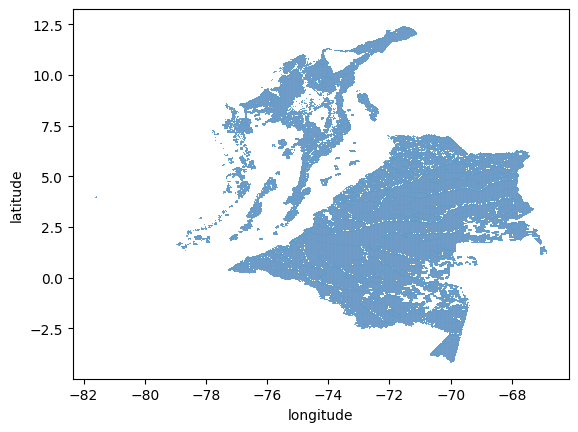

In [ ]:
sns.scatterplot(data=r,x='longitude',y='latitude',s=0.5)

In [ ]:
X= np.loadtxt('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_filtered.csv',skiprows=1,delimiter=',', usecols=(2,3,5)) # se carga el archivo .csv
X -= np.mean(X,axis=0) # Se deben normalizar las variables para que sean comparables# Se deben normalizar las variables para que sean comparables
X /= np.std(X,axis=0)

X.shape

(494254, 3)

<ipython-input-216-14931ae3551f>:6: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=r,x='longitude',y='latitude',hue='label',s=1,palette=sns.color_palette("tab10")) #Imagen para artículo


<Axes: xlabel='longitude', ylabel='latitude'>

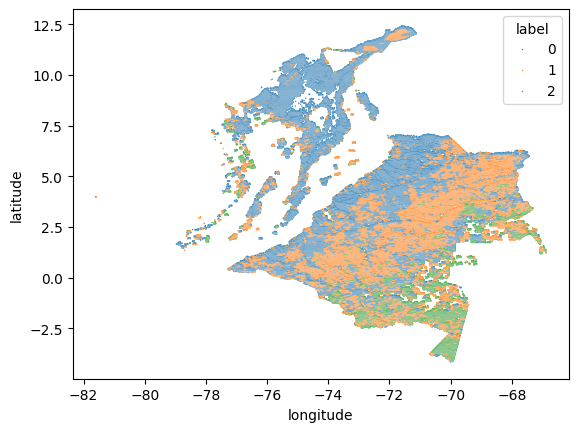

In [ ]:
alpha_star=3
kmeans = KMeans(n_clusters=alpha_star, random_state=0, n_init='auto').fit(X)
labe=kmeans.labels_
r['label']=labe
r
sns.scatterplot(data=r,x='longitude',y='latitude',hue='label',s=1,palette=sns.color_palette("tab10")) #Imagen para artículo

In [ ]:
sns.scatterplot(data=r,x='longitude',y='latitude',hue='label',s=1,palette=sns.color_palette("tab10")) #Imagén para artículo

# Clasificación

Debido a que anteriormente, ningún clasificador hizo un buen trabajo, y simplemente tomaba toda la región del país como perteneciente a una misma intancia, se busca crear una red neuronal que haga la tarea de clasificación.

In [ ]:
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F


In [ ]:
y=labe
X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)

In [ ]:
X_train.shape

(420383, 2)

In [ ]:
class Data(Dataset):
  def __init__(self, X_train, y_train):
    # need to convert float64 to float32 else
    # will get the following error
    # RuntimeError: expected scalar type Double but found Float
    self.X = torch.from_numpy(X_train.astype(np.float32))
    # need to convert float64 to Long else
    # will get the following error
    # RuntimeError: expected scalar type Long but found Float
    self.y = torch.from_numpy(y_train).type(torch.LongTensor)
    self.len = self.X.shape[0]

  def __getitem__(self, index):
    return self.X[index], self.y[index]
  def __len__(self):
    return self.len

In [ ]:
traindata = Data(X_train, Y_train)
print(traindata[25])

(tensor([-1.2128,  0.1842]), tensor(0))


In [ ]:

# number of features (len of X cols)
input_dim = 2
# number of hidden layers
hidden_layers = 25
#hidden_layers2 = 125
# number of classes (unique of y)
output_dim = 3
class Network(nn.Module):
    def __init__(self,hidden_layers):
        super(Network, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_layers)
        #self.linearh1=nn.Linear(hidden_layers,hidden_layers2)
        self.linear2 = nn.Linear(hidden_layers, output_dim)
    def forward(self, x):
        x = F.leaky_relu(self.linear1(x))
        #x = torch.sigmoid(self.linearh1(x))
        x = self.linear2(x)
        #x = F.softmax(x)
        return x


In [ ]:
epochs = 40
def run_epoch(epoch,ta,clf):
    criterion = nn.MultiMarginLoss()#nn.MultiMarginLoss()#nn.HingeEmbeddingLoss#nn.MultiLabelMarginLoss()##
    optimizer = torch.optim.Adam(clf.parameters(), lr=ta)
    for epoch in range(epochs):
      running_loss = 0.0
      for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        # set optimizer to zero grad to remove previous epoch gradients
        optimizer.zero_grad()
        # forward propagation
        outputs = clf(inputs)
        loss = criterion(outputs, labels)
        # backward propagation
        loss.backward()
        # optimize
        optimizer.step()
        running_loss += loss.item()
      # display statistics
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.5f}')

In [ ]:
def test_val(clf):
    correct, total = 0, 0
    # no need to calculate gradients during inference
    with torch.no_grad():
      for data in testloader:
        inputs, labels = data
        # calculate output by running through the network
        outputs = clf(inputs)
        # get the predictions
        __, predicted = torch.max(outputs.data, 1)
        # update results
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Accuracy of the network on the {len(testdata)} test data: {100 * correct // total} %')
    return correct/total

In [ ]:
def parameters_train(ep,ta,hl):
    #nn_arch(hidden_layers)
    clf = Network(hl)
    epochs = ep
    lr=ta
    run_epoch(epoch,lr,clf)
    score=test_val(clf)
    return score

In [ ]:
#Se busca el mejor parámetro para la cantidad de capas ocultas
hd=np.arange(2,30,5)
epoch=40
lr=0.005
val_scores_hl=[]
batch_size = 20000
cv=3
for hidden_layers in hd:
    print(hidden_layers)
    val_scores_hl_cv=[]
    for j in range(cv):
        X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
        traindata = Data(X_train, Y_train)
        trainloader = DataLoader(traindata, batch_size=batch_size,
                         shuffle=True, num_workers=2)
        testdata = Data(X_test, Y_test)
        testloader = DataLoader(testdata, batch_size=batch_size,
                                shuffle=True, num_workers=2)
        val_scores_hl_cv.append(parameters_train(epoch,lr,hidden_layers))
    val_scores_hl.append(np.mean(val_scores_hl_cv))

2
[40,    22] loss: 0.00079
Accuracy of the network on the 207055 test data: 88 %
[40,    22] loss: 0.00067
Accuracy of the network on the 207055 test data: 88 %


KeyboardInterrupt: 

HL_star = 10


ValueError: x and y must have same first dimension, but have shapes (6,) and (0,)

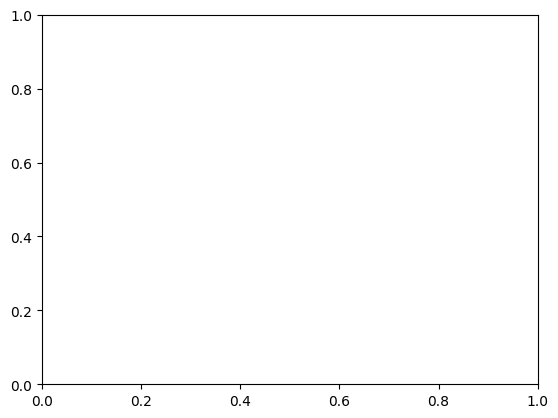

In [ ]:
#Se encuentra la mejor cantidad de puntos en la capa oculta
ind = np.argmax(val_scores_hl)
hl_star = 10#hd[ind] #Resultó ser 13
print('HL_star =', hl_star)

plt.plot(hd,val_scores_hl)
plt.plot(np.ones(11)*hl_star,np.arange(0,1.1,0.1),'--r')
#plt.xlim(0.9,1)
plt.ylim(0.9,1)
plt.xlabel('HL')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

In [ ]:
# Se busca el mejor valor para la tasa de aprendizaje
epoch=40
lr=np.arange(1e-5,0.01,5e-4)
val_scores_lr=[]
batch_size = 500
cv=4
for i in lr:
    #print(clf.parameters)
    print(i)
    val_scores_lr_cv=[]
    for j in range(cv):
        X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
        traindata = Data(X_train, Y_train)
        trainloader = DataLoader(traindata, batch_size=batch_size,
                         shuffle=True, num_workers=2)
        testdata = Data(X_test, Y_test)
        testloader = DataLoader(testdata, batch_size=batch_size,
                                shuffle=True, num_workers=2)
        val_scores_lr_cv.append(parameters_train(epoch,i,hl_star))
    val_scores_lr.append(np.mean(val_scores_lr_cv))

In [ ]:
ind = np.argmax(val_scores_lr)
lr_star = lr[ind]
print('LR_star =', lr_star)

plt.plot(lr,val_scores_lr)
plt.plot(np.ones(11)*lr_star,np.arange(0,1.1,0.1),'--r')
#plt.xlim(0.95,1)
plt.ylim(0.95,1)
plt.xlabel('Learning Rate')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

LR_star = 0.005


NameError: name 'val_scores_lr' is not defined

In [ ]:
#plt.scatter(inputs[:,0],inputs[:,1],c=predicted)
parameters_train(40,0.005,15)

[40,    22] loss: 0.00096
Accuracy of the network on the 207055 test data: 88 %


0.8830117601603439

In [ ]:
# save the trained model
hl_star=15
clf = Network(hl_star)
criterion = nn.MultiMarginLoss()#nn.MultiMarginLoss()#nn.HingeEmbeddingLoss#nn.MultiLabelMarginLoss()##
optimizer = torch.optim.Adam(clf.parameters(), lr=lr_star)
epochs = 40
for epoch in range(epochs):
  running_loss = 0.0
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    # set optimizer to zero grad to remove previous epoch gradients
    optimizer.zero_grad()
    # forward propagation
    outputs = clf(inputs)
    loss = criterion(outputs, labels)
    # backward propagation
    loss.backward()
    # optimize
    optimizer.step()
    running_loss += loss.item()
  # display statistics
  print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.5f}')
PATH = '/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/mymodel_prueba2.pth'
torch.save(clf.state_dict(), PATH)

[1,    22] loss: 0.00590
[2,    22] loss: 0.00409
[3,    22] loss: 0.00250
[4,    22] loss: 0.00168
[5,    22] loss: 0.00144
[6,    22] loss: 0.00131
[7,    22] loss: 0.00124
[8,    22] loss: 0.00120
[9,    22] loss: 0.00117
[10,    22] loss: 0.00115
[11,    22] loss: 0.00113
[12,    22] loss: 0.00112
[13,    22] loss: 0.00112
[14,    22] loss: 0.00113
[15,    22] loss: 0.00110
[16,    22] loss: 0.00111
[17,    22] loss: 0.00110
[18,    22] loss: 0.00109
[19,    22] loss: 0.00109
[20,    22] loss: 0.00109
[21,    22] loss: 0.00109
[22,    22] loss: 0.00108
[23,    22] loss: 0.00106
[24,    22] loss: 0.00104
[25,    22] loss: 0.00103
[26,    22] loss: 0.00104
[27,    22] loss: 0.00104
[28,    22] loss: 0.00103
[29,    22] loss: 0.00102
[30,    22] loss: 0.00102
[31,    22] loss: 0.00102
[32,    22] loss: 0.00103
[33,    22] loss: 0.00102
[34,    22] loss: 0.00101
[35,    22] loss: 0.00102
[36,    22] loss: 0.00101
[37,    22] loss: 0.00100
[38,    22] loss: 0.00101
[39,    22] loss: 0.0

In [ ]:
# load the trained model
clf = Network(hl_star)
clf.load_state_dict(torch.load(PATH))

<ipython-input-110-07824202a065>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  clf.load_state_dict(torch.load(PATH))


<All keys matched successfully>

In [ ]:
# mapa con la clasificación de resultado
#sns.scatterplot(x=inputs[:,0],y=inputs[:,1])#],hue='label',s=1,palette=sns.color_palette("tab10"))
batch_size=len(y)
wdata = Data(X[:,[0,1]], y)
dataloader = DataLoader(wdata, batch_size=batch_size,
                                shuffle=True, num_workers=2)
y_pred=[]
for data in dataloader:
    inputs, labels = data
    # calculate output by running through the network
    outputs = clf(inputs)
    # get the predictions
    __, predicted = torch.max(outputs.data, 1)
    y_pred.append(predicted)
#r['region']=predicted
# fig, ax = plt.subplots()
# for label in [0, 1,2,3]:
#     mask = (y_pred == label)
#     ax.scatter(inputs[mask, 0], inputs[mask, 1],s=0.3)
#plt.scatter(inputs[:,0],inputs[:,1],c=predicted)


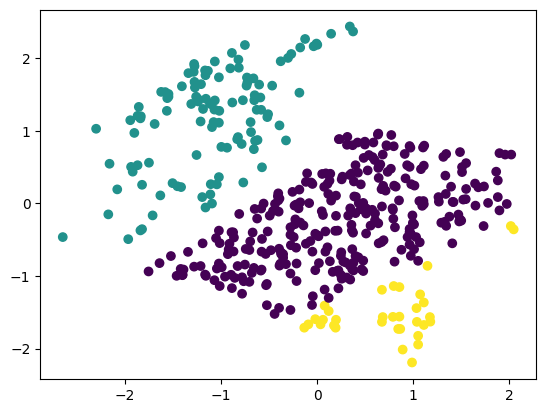

In [ ]:
plt.scatter(inputs[:,1],inputs[:,0],c=predicted)

<Axes: xlabel='longitude', ylabel='latitude'>

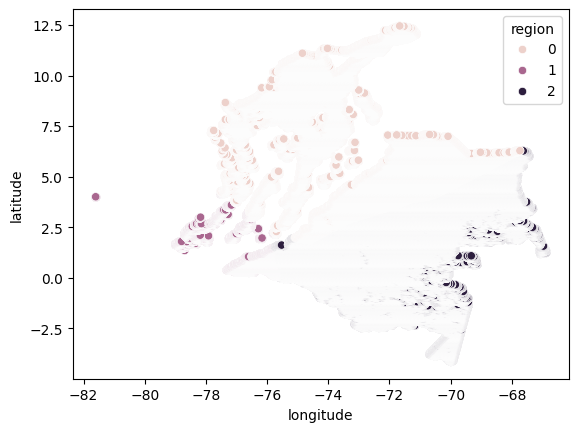

In [ ]:
r['region']=predicted
sns.scatterplot(data=r,x='longitude',y='latitude',hue='region')

array([[-2.24790812,  1.00495578],
       [-2.24504082,  1.00072485],
       [-2.24217352,  0.99649392],
       ...,
       [ 2.51467418,  0.31108332],
       [ 2.51754148,  0.2941596 ],
       [ 2.51754148,  0.29839053]])

# Series de tiempo

In [ ]:
#Crear los dataframes a partir de la clasificación
df_car.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Caribe')
df_valle.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Valle')
df_amazon.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Amazonía')
df_orin.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Orinoquía')
df_pacif.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Pacífico')
#df_bog.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Bogotá')
df.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Colomibia')
plt.legend()
plt.ylabel('Methane concentration [ppb]')
plt.xlabel('Date')
plt.title('Methane Time Series for Colombian regions')
plt.grid()

In [ ]:
series1=df.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series1_std=df.groupby(['year','month']).std()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series2=df_amazon.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series2_std=df_amazon.groupby(['year','month']).std()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
df_mean=pd.merge(series1,series2, on=['year','month'])
df_std=pd.merge(series1_std,series2_std, on=['year','month'])
df_mean

In [ ]:
import scipy.stats as stats

series1=df_mean['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_x']
series1_std=df_std['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_x']
series2=df_mean['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_y']
series2_std=df_std['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_y']
t_stat, p_value = stats.ttest_ind_from_stats(
    mean1=np.array(series1),
    std1=np.array(series1_std),
    nobs1=len(series1),
    mean2=np.array(series2),
    std2=np.array(series2_std),
    nobs2=len(series2),
    alternative='greater'
)
print(sum(p_value*100>5)/len(series1)*100) #porcentaje en el que no hay evidencia suficiente para rechazar la hipótesis
print(sum(p_value*100<0.1)/len(series1)*100) # Porcentaje en el que hay evidencia indistutible para rechazar la hipótesis nula
#print(max(p_value)*100)
i_p=np.argwhere(p_value>0.05)
ind[i_p]

In [ ]:
t_stat, p_value = stats.ttest_ind(series1, series2, equal_var=False,alternative='greater')
print(p_value*100) # comparación de medias, Evidencia indiscutible

In [ ]:
#Se sospecha que no siempre es menor el metano en el Amazonas, por lo que se hace prueba de hipótesis entre promedios multianuales
series1m=df.groupby(['month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series1_stdm=df.groupby(['month']).std()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series2m=df_amazon.groupby(['month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series2_stdm=df_amazon.groupby(['month']).std()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
t_statm, p_valuem = stats.ttest_ind_from_stats(
    mean1=np.array(series1m),
    std1=np.array(series1_stdm),
    nobs1=len(series1m),
    mean2=np.array(series2m),
    std2=np.array(series2_stdm),
    nobs2=len(series2m),
    alternative='greater'
)
print(p_valuem*100<5)
print(p_valuem*100) # No se puede refutar la hipótesis de que el Amazonas tenga menores niveles de metano en los meses de Enero, Febrero, Marzo y Diciembre

In [ ]:
df_tsc=pd.read_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/CH4_completo.csv',skiprows=1)
df_tsc=df_tsc[(df_tsc['value']>1850)*(df_tsc['year']>2015)]
df_tsc.groupby(['year','month'])['value'].mean().plot()
plt.ylabel('Methane concentration [ppb]')
plt.xlabel('Month')
plt.title('Methane Time Series reference value')
plt.grid()


In [ ]:
df_g=pd.read_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/ch4_mm_gl.csv',skiprows=45)
df_g=df_g[df_g['year']>2015]
df_g.groupby(['year','month'])['average'].mean().plot()
plt.ylabel('Methane concentration [ppb]')
plt.xlabel('Month')
plt.title('Methane Time Series global value')
plt.grid()

In [ ]:
df_c_b=pd.merge(df,df_c, on=['year','month'])
df_c_r=pd.merge(df_c_b,df_g,on=['year','month'])
df_c_r

In [ ]:
df_c_r.groupby(['year','month'])['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].mean().plot(label='Colombia')
df_c_r.groupby(['year','month'])['average'].mean().plot(label='Global')
df_c_r.groupby(['year','month'])['value'].mean().plot(label='Barbados')
plt.legend()
plt.ylabel('Methane concentration [ppb]')
plt.xlabel('Date')
plt.title('Methane Time Series for Colombia vs reference value')
plt.grid()

# Detección de anomalías

In [ ]:
X= np.loadtxt(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered.csv',skiprows=1, usecols=(1,2,4),delimiter=',')
X

array([[ -77.305     ,    7.745     , 1866.55965028],
       [ -77.305     ,    7.755     , 1866.55961485],
       [ -77.295     ,    7.705     , 1866.55956703],
       ...,
       [ -67.325     ,    3.455     , 1835.4564209 ],
       [ -67.315     ,    3.435     , 1835.45643867],
       [ -67.315     ,    3.445     , 1835.4564209 ]])

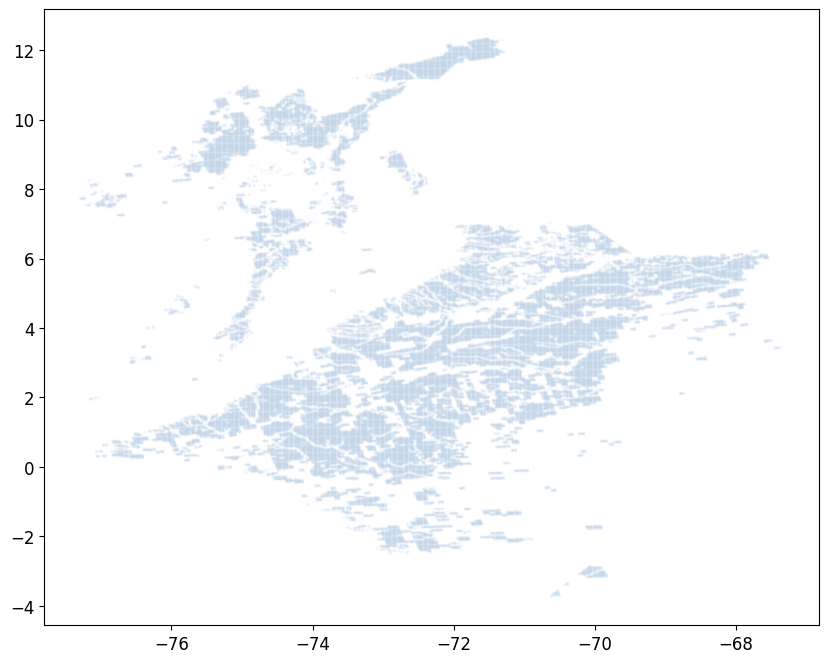

In [ ]:
plt.scatter(X[:,0],X[:,1],s=0.0001)

In [ ]:
def prepData(processed_data,iSplit=0.5):
    # gaia_vars=['phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag']
    # var0=(igaia_data[gaia_vars[0]]-idist.distmod).value
    # var1=(igaia_data[gaia_vars[1]]-idist.distmod).value
    # var2=(igaia_data[gaia_vars[2]]-idist.distmod).value
    # var3=igalcen.x.value
    # var4=igalcen.y.value
    # var5=igalcen.z.value
    # var6=igalcen.v_x.value
    # var7=igalcen.v_y.value
    # var8=igalcen.v_z.value

    #processed_data = np.vstack((var0,var1,var2,var3,var4,var5,var6,var7,var8))
    # processed_data = np.vstack((var0,var1,var2,var3,var4,var5,var6,var7,var8))
    # processed_data = processed_data.T
    # processed_data = processed_data[~np.isnan(processed_data).any(axis=1)]
    processed_data_raw = processed_data.copy()

    #normalize the data
    processed_data -= np.mean(processed_data,axis=0)
    processed_data /= np.std(processed_data,axis=0)
    processed_data = processed_data[~np.isnan(processed_data).any(axis=1)]

    #pytorch the layer
    tprocessed_data = torch.tensor(processed_data).float()
    processed_data_raw = processed_data_raw[~torch.any(tprocessed_data.isnan(),dim=1)]
    #galcen_clean       = igalcen[~torch.any(tprocessed_data.isnan(),dim=1)]
    n_samples=processed_data.shape[0]
    indices = np.arange(n_samples)
    #split
    X_train, X_test, Y_train, Y_test = train_test_split(processed_data, indices, test_size=iSplit)
    maxindex       = int(len(processed_data)*iSplit)
    trainset       = torch.tensor(X_train).float()
    trainset       = trainset[~torch.any(trainset.isnan(),dim=1)]
    testset        = torch.tensor(X_test).float()
    testset        = testset[~torch.any(testset.isnan(),dim=1)]
    print(processed_data_raw.shape,testset.shape,trainset.shape)
    return testset,trainset,processed_data_raw,tprocessed_data, Y_train, Y_test #,galcen_clean

#btestset,btrainset,bprocessed_data_raw,btprocessed_data,bgalcen_clean=prepData(gaia_data,dist,galcen)
btestset,btrainset,bprocessed_data_raw,btprocessed_data,index_train,index_test=prepData(X)

(248583, 3) torch.Size([124292, 3]) torch.Size([124291, 3])


In [ ]:
#autoencoder para que la red neuronal aprenda las características más relevantes de los datos
class MLP(nn.Module):
    def __init__(self,n_inputs,n_outputs):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_inputs, 20),
            nn.LeakyReLU(),
            nn.Linear(20, 6),
            nn.ReLU(),
            nn.Linear(6, 2),
            nn.ReLU(),
            nn.Linear(2, 6),
            nn.ReLU(),
            nn.Linear(6, 20),
            nn.ReLU(),
            nn.Linear(20, n_outputs),
        )

    def forward(self, x):
        x = self.layers(x)
        return x

def train(x,y,net,loss_func,opt,sched,nepochs):
    net.train(True)
    for epoch in range(nepochs):
        prediction = net(x)
        opt.zero_grad()
        loss = loss_func(prediction,y)
        loss.backward()
        opt.step()
        if epoch % 500 == 0:
            print('[%d] loss: %.4f ' % (epoch + 1, loss.item()  ))
    #sched.step()
    return

basicmodel     = MLP(btrainset.shape[1],1)#btrainset.shape[1])
optimizer = torch.optim.Adam(basicmodel.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1, last_epoch=-1, verbose=False)
loss_fn   =  nn.MSELoss(reduction='sum')

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
train(btrainset,btrainset[:,2:],basicmodel,loss_fn,optimizer,scheduler,5001)

[1] loss: 129738.1250 
[501] loss: 13.7357 
[1001] loss: 3.1057 
[1501] loss: 1.4005 
[2001] loss: 41.8342 
[2501] loss: 0.5517 
[3001] loss: 0.5454 
[3501] loss: 0.2444 
[4001] loss: 0.1989 
[4501] loss: 0.1076 
[5001] loss: 0.0875 


In [ ]:
btrainset.shape

torch.Size([124291, 3])

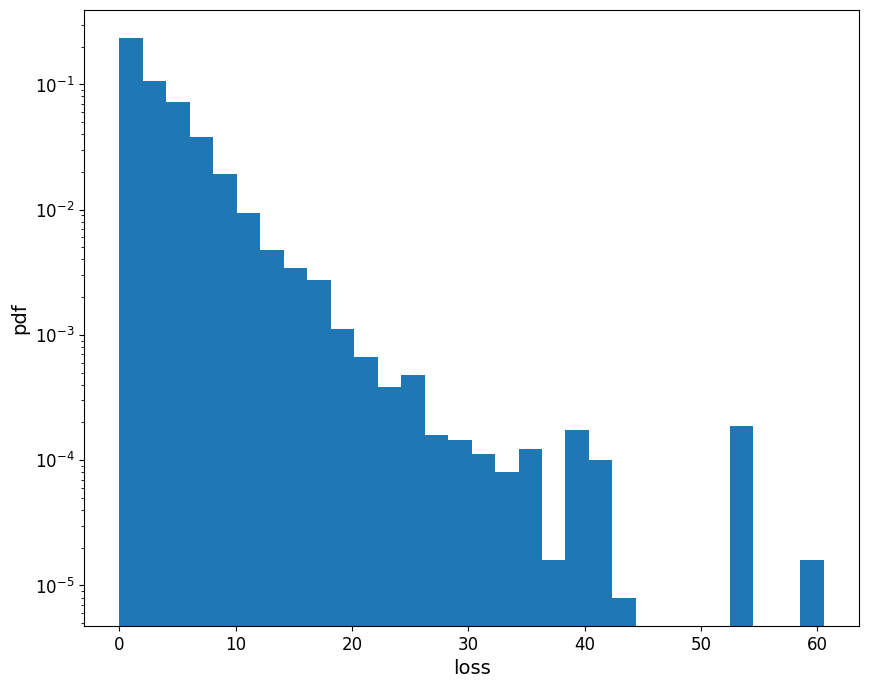

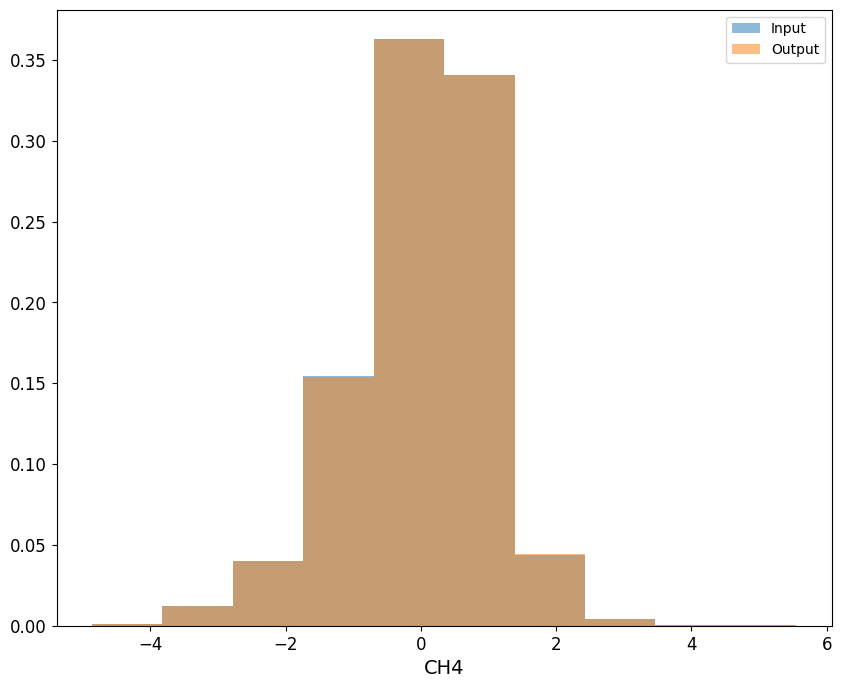

In [ ]:
basicmodel.train(False)
boutput=basicmodel(btestset)
btestloss=torch.sum((btestset-boutput)**2,axis=1)
#btestloss2=torch.sum((btestset-boutput)**1,axis=1)
plt.hist(btestloss[btestloss < 100].detach().numpy(),density=True,bins=30)
plt.yscale('log')
plt.xlabel('loss')
plt.ylabel('pdf')
plt.show()

varlabels=['longitude','latitude','CH4']#['Mag','B-Mag','R-Mag','x','y','z','vx','vy','vz']
_,bins,_=plt.hist(btestset[:,2].detach().numpy(),density=True,alpha=0.5,label='Input')
plt.hist(boutput.detach().numpy(),density=True,alpha=0.5,bins=bins,label='Output')
plt.xlabel(varlabels[2])
plt.legend()
# fig, ax = plt.subplots(3, 3, figsize=(20, 20))
# for var in range(btestset.shape[1]):
#     _,bins,_=ax[var//3,var % 3].hist(btestset[:,var].detach().numpy(),density=True,alpha=0.5,label='Input')
#     ax[var//3,var % 3].hist(boutput [:,var].detach().numpy(),density=True,alpha=0.5,bins=bins,label='Output')
#     ax[var//3,var % 3].set_xlabel(varlabels[var])
#     ax[var//3,var % 3].legend()

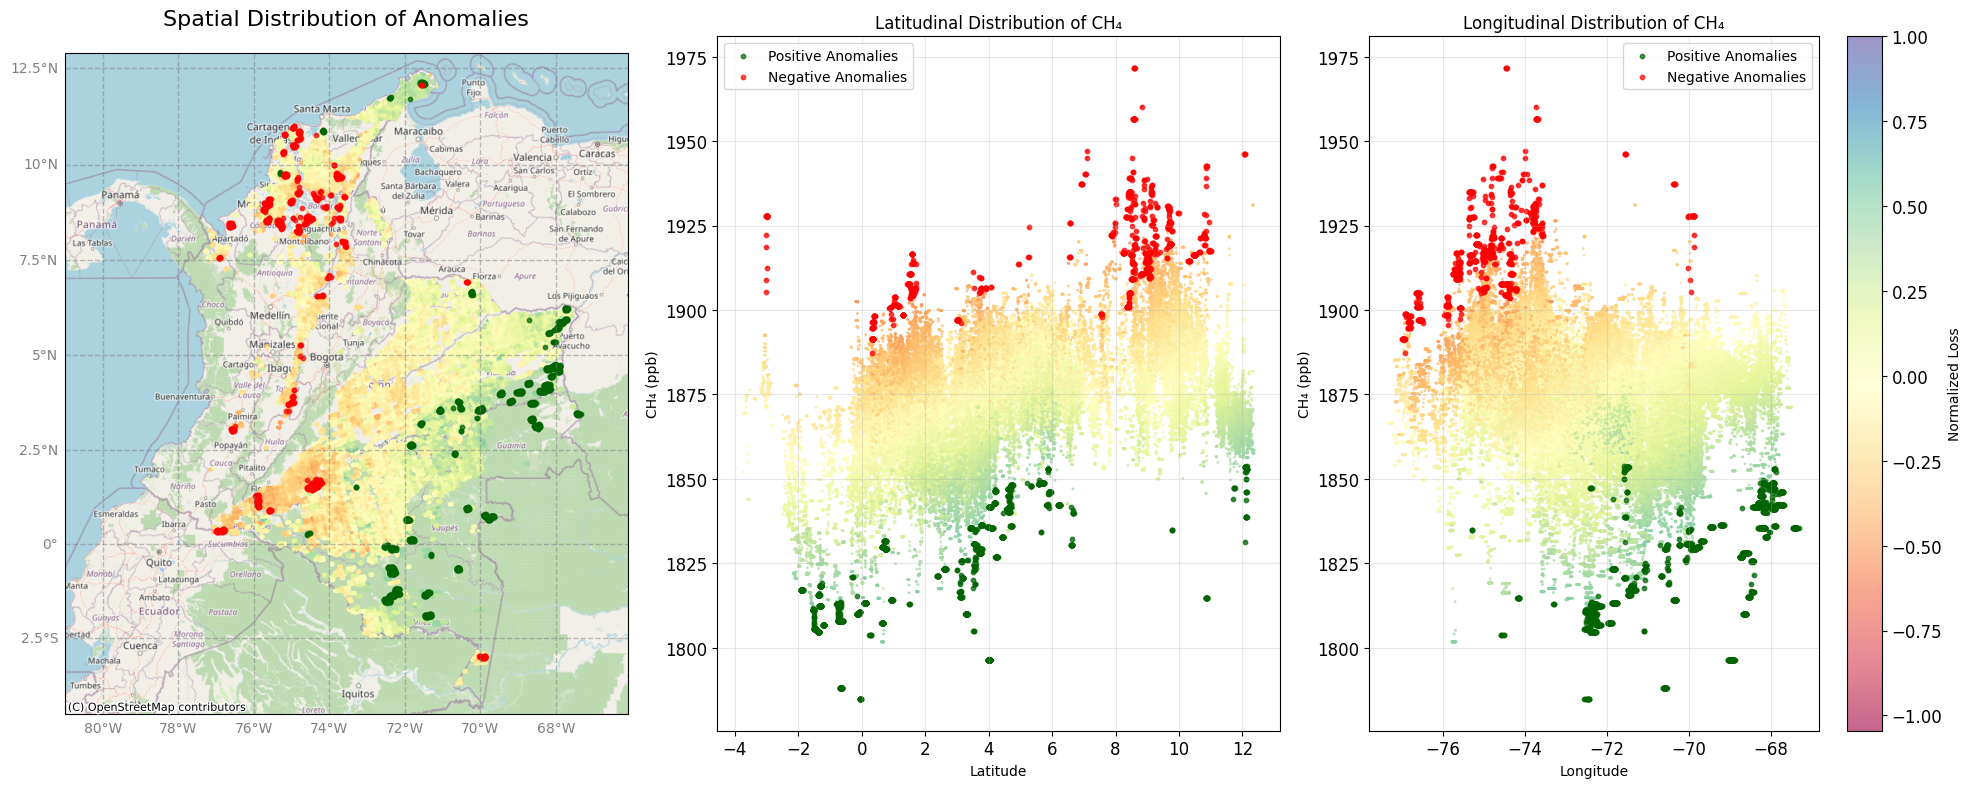

In [ ]:
def plotAnomaly(iCut, iRaw, iLoss, i_test, iLoss2, maxlosscolor=20, figsize=(20, 8),
                save_plot=False, filename='anomaly_plot.png'):
    """
    Plot anomalies in methane data with enhanced visualization and map background.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import cartopy.crs as ccrs
    import contextily as cx
    from matplotlib.gridspec import GridSpec
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

    # Prepare the data
    loss = np.minimum(iLoss2, maxlosscolor)
    anomalies = (iLoss > iCut)
    btestdata_raw = iRaw[i_test]

    # Separate positive and negative anomalies
    pos_anomaly_raw = btestdata_raw[anomalies*(iLoss2>0)]
    neg_anomaly_raw = btestdata_raw[anomalies*(iLoss2<0)]
    anomaly_raw = btestdata_raw[anomalies]

    # Normalize loss values
    loss = loss/np.max(loss)
    if maxlosscolor != 20:
        loss = np.ones(loss.shape)

    # Create figure with GridSpec
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 3, figure=fig)

    # Map plot with anomalies
    ax1 = fig.add_subplot(gs[0], projection=ccrs.epsg(3857))

    # Set map extent for Colombia
    extent = [-81, -66.1, -4.5, 12.9]
    ax1.set_extent(extent, crs=ccrs.PlateCarree())

    # Plot points on map
    scat = ax1.scatter(btestdata_raw[:,0], btestdata_raw[:,1],
                      marker='.', c=loss, cmap="Spectral",
                      transform=ccrs.PlateCarree(),
                      s=5, alpha=0.6)

    # Plot anomalies
    ax1.scatter(pos_anomaly_raw[:,0], pos_anomaly_raw[:,1],
                c='#006400', s=10, alpha=0.7,
                label='Positive Anomalies',
                transform=ccrs.PlateCarree())
    ax1.scatter(neg_anomaly_raw[:,0], neg_anomaly_raw[:,1],
                c='red', s=10, alpha=0.7,
                label='Negative Anomalies',
                transform=ccrs.PlateCarree())

    # Add basemap
    cx.add_basemap(ax1, source=cx.providers.OpenStreetMap.Mapnik)

    # Add gridlines
    gl = ax1.gridlines(crs=ccrs.PlateCarree(),
                      draw_labels=True,
                      linewidth=1,
                      color='gray',
                      alpha=0.5,
                      linestyle='--')

    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'gray'}
    gl.ylabel_style = {'size': 10, 'color': 'gray'}

    # # Add legend
    # legend = ax1.legend(title='Anomalies',
    #                    loc='upper left',
    #                    bbox_to_anchor=(1.05, 1),
    # #                    markerscale=3)
    # plt.setp(legend.get_title(), fontsize=10)

    ax1.set_title('Spatial Distribution of Anomalies', pad=20)

    # Latitude-CH4 plot
    ax2 = fig.add_subplot(gs[1])
    scat2 = ax2.scatter(btestdata_raw[:,1], btestdata_raw[:,2],
                       c=loss, marker='.', cmap="Spectral",
                       s=5, alpha=0.6)
    ax2.scatter(pos_anomaly_raw[:,1], pos_anomaly_raw[:,2],
                c='#006400', s=10, alpha=0.7,
                label='Positive Anomalies')
    ax2.scatter(neg_anomaly_raw[:,1], neg_anomaly_raw[:,2],
                c='red', s=10, alpha=0.7,
                label='Negative Anomalies')
    ax2.set_xlabel("Latitude", fontsize=10)
    ax2.set_ylabel("CH₄ (ppb)", fontsize=10)
    ax2.set_title('Latitudinal Distribution of CH₄', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # Longitude-CH4 plot
    ax3 = fig.add_subplot(gs[2])
    scat3 = ax3.scatter(btestdata_raw[:,0], btestdata_raw[:,2],
                       c=loss, marker='.', cmap="Spectral",
                       s=5, alpha=0.6)
    ax3.scatter(pos_anomaly_raw[:,0], pos_anomaly_raw[:,2],
                c='#006400', s=10, alpha=0.7,
                label='Positive Anomalies')
    ax3.scatter(neg_anomaly_raw[:,0], neg_anomaly_raw[:,2],
                c='red', s=10, alpha=0.7,
                label='Negative Anomalies')
    ax3.set_xlabel("Longitude", fontsize=10)
    ax3.set_ylabel("CH₄ (ppb)", fontsize=10)
    ax3.set_title('Longitudinal Distribution of CH₄', fontsize=12)
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # Add colorbar
    cbar = plt.colorbar(scat3, ax=ax3)
    cbar.set_label('Normalized Loss', fontsize=10)

    # Adjust layout
    plt.tight_layout()

    # Save plot if requested
    if save_plot:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

    return pos_anomaly_raw, neg_anomaly_raw, anomaly_raw
# def plotAnomaly(iCut,iRaw,iLoss,i_test,iLoss2,maxlosscolor=20):
#     loss = np.minimum(iLoss2,maxlosscolor)
#     anomalies=(iLoss > iCut)

#     #baseidex=len(iRaw)-len(iLoss)
#     btestdata_raw = iRaw[i_test]
#     pos_anomaly_raw=btestdata_raw[anomalies*(iLoss2>0)]
#     neg_anomaly_raw=btestdata_raw[anomalies*(iLoss2<0)]
#     anomaly_raw  = btestdata_raw[anomalies]
#     # pos_anomaly= anomaly_raw[iLoss2>0]
#     # neg_anomaly= anomaly_raw[iLoss2<0]
#     #btestgalcen   = igalcen[baseidex:]#
#     #anomaly_galcen = btestgalcen[anomalies]#
#     #print(anomaly_raw)
#     vma=1
#     vmi=-1*vma
#     loss = loss/np.max(loss)
#     if maxlosscolor != 20:
#         loss=np.ones(loss.shape)
#     print(loss.shape,btestdata_raw[:,2].shape)
#     scat=plt.scatter(btestdata_raw[:,0],btestdata_raw[:,1], marker='.',c=loss,cmap="Spectral")
#     plt.plot(anomaly_raw[:,0],anomaly_raw[:,1], marker='.', linestyle='none',c='orange')
#     plt.xlabel('$Longitude$')
#     plt.ylabel('$Latitude$')
#     #plt.ylim(15,0)
#     #plt.xlim(1,-5)
#     plt.colorbar(scat)
#     plt.show()
#     plt.figure(figsize=(16,4))
#     plt.subplot(1,3,1)
#     scat=plt.scatter(btestdata_raw[:,0],btestdata_raw[:,1], marker='.',c=loss,cmap="Spectral", vmin=vmi, vmax=vma)
#     plt.plot(pos_anomaly_raw[:,0],pos_anomaly_raw[:,1], marker='.', linestyle='none',c='#006400')
#     plt.plot(neg_anomaly_raw[:,0],neg_anomaly_raw[:,1], marker='.', linestyle='none',c="#FF0000")
#     plt.xlabel('$Longitude$')
#     plt.ylabel('$Latitude$')
#     #plt.ylim(15,0)
#     #plt.xlim(1,-5)
#     #plt.colorbar(scat)
#     #plt.show()
#     plt.subplot(1,3,2)
#     scat=plt.scatter(btestdata_raw[:,1],btestdata_raw[:,2],c=loss, marker='.',cmap="Spectral",vmin=vmi, vmax=vma)
#     plt.plot(pos_anomaly_raw[:,1],pos_anomaly_raw[:,2], marker='.', linestyle='none',c='#006400')
#     plt.plot(neg_anomaly_raw[:,1],neg_anomaly_raw[:,2], marker='.', linestyle='none',c='red')
#     #plt.plot(anomaly_raw[:,1],anomaly_raw[:,2], marker='.', linestyle='none',c='orange')
#     plt.xlabel("$Latitude$")
#     plt.ylabel("CH4[ppb]")
#     #plt.colorbar(scat)
#     #plt.show()
#     plt.subplot(1,3,3)
#     scat=plt.scatter(btestdata_raw[:,0],btestdata_raw[:,2],c=loss, marker='.', cmap="Spectral", vmin=vmi, vmax=vma)
#     plt.plot(pos_anomaly_raw[:,0],pos_anomaly_raw[:,2], marker='.', linestyle='none',c='#006400')
#     plt.plot(neg_anomaly_raw[:,0],neg_anomaly_raw[:,2], marker='.', linestyle='none',c='red')
#     #plt.plot(anomaly_raw[:,0],anomaly_raw[:,2], marker='.', linestyle='none',c='orange')
#     plt.xlabel("$Longitude$")
#     plt.ylabel("CH4[ppb]")
#     plt.colorbar(scat)
#     plt.show()
#     return pos_anomaly_raw,neg_anomaly_raw,anomaly_raw
    # scat=plt.scatter(btestdata_raw[:,6],btestdata_raw[:,7],c=loss, marker='.', cmap="viridis")
    # plt.plot(anomaly_raw[:,6],anomaly_raw[:,7], marker='.', linestyle='none',c='orange')
    # plt.xlabel("vx[pc]")
    # plt.ylabel("vy[pc]")
    # plt.colorbar(scat)
    # plt.show()

    # scat=plt.scatter(btestdata_raw[:,6],btestdata_raw[:,8],c=loss, marker='.',cmap="viridis")
    # plt.plot(anomaly_raw[:,6],anomaly_raw[:,8], marker='.', linestyle='none')
    # plt.xlabel("vx[pc]")
    # plt.ylabel("vz[pc]")
    # plt.show()

    # print(len(btestdata_raw),len(iRaw),len(igalcen),len(btestgalcen))
    # H = gp.Hamiltonian(milky_way)
    # w0_anom = gd.PhaseSpacePosition(anomaly_galcen.cartesian)
    # orbits_anom = H.integrate_orbit(w0_anom, dt=1*u.Myr, t1=0*u.Myr, t2=100*u.Myr)
    # w0_all  = gd.PhaseSpacePosition(bgalcen_clean[1==1].cartesian)
    # orbits_all  = H.integrate_orbit(w0_all,  dt=1*u.Myr, t1=0*u.Myr, t2=100*u.Myr)

    # zmax_all = orbits_all.zmax(approximate=True)
    # zmax_anom = orbits_anom.zmax(approximate=True)
    # print("ZMax mean:",zmax_anom[~np.isnan(zmax_anom.value)].mean(),len(zmax_anom),"default:",zmax_all.mean())
    # bins = np.linspace(0, 10, 50)
    # plt.hist(zmax_all.value, bins=bins, alpha=0.4, density=True, label='all')
    # plt.hist(zmax_anom.value, bins=bins, alpha=0.4, density=True, label='anom')
    # plt.legend(loc='best', fontsize=14)
    # plt.yscale('log')
    # plt.xlabel(r" zmax" + " [{0:latex}]".format(zmax_all.unit))
    # plt.show()

    # zmax_all  = orbits_all.eccentricity()
    # zmax_anom = orbits_anom.eccentricity()
    # print("Ecc mean:",zmax_anom[~np.isnan(zmax_anom.value)].mean(),len(zmax_anom),"default:",zmax_all.mean())
    # bins = np.linspace(0, 3, 50)
    # plt.hist(zmax_all.value,  bins=bins, alpha=0.4, density=True, label='all')
    # plt.hist(zmax_anom.value, bins=bins, alpha=0.4, density=True, label='anom')
    # plt.legend(loc='best', fontsize=14)
    # plt.yscale('log')
    # plt.xlabel('Eccentricity')
    # plt.show()
# cutoff 20 whole average, 14 prom 2020
btestloss2=torch.sum((btestset-boutput)**1,axis=1)
positive_anomaly,negative_anomaly,anomaly=plotAnomaly(14,bprocessed_data_raw,btestloss.detach().numpy(),index_test,btestloss2.detach().numpy())#,bgalcen_clean)


In [ ]:
#Relacionar con el uso de la tierra en puntos anomalos
encoded_df45=encoded_df[~((encoded_df['Leyenda_1_4. Wet areas']>0)+(encoded_df['Leyenda_1_5. Water surfaces']>0))]
#encoded_df45=encoded_df[encoded_df['Leyenda_3_1.3.1. Zonas de extracción minera']>0]
#encoded_df45=encoded_df.copy()

In [ ]:
#encoded_df.geometry.intersects(positive_anomaly)
# This will return a boolean Series
for i in range(len(positive_anomaly)):
  is_within = encoded_df45.geometry.contains(Point(positive_anomaly[i,0], positive_anomaly[i,1]))
  encoded_df45.loc[is_within,'groupb']=1
# encoded_df2=encoded_df45.copy()
# encoded_df2['groupb']=0
for i in range(len(negative_anomaly)):
  is_within = encoded_df45.geometry.contains(Point(negative_anomaly[i,0], negative_anomaly[i,1]))
  encoded_df45.loc[is_within,'groupb']=2
#encoded_df2[encoded_df2['groupb']==1].geometry
#encoded_df45[encoded_df45['groupb']==1].geometry

In [ ]:
l_in=list(encoded_df45.columns)
pos_level3=encoded_df45[encoded_df45['groupb']==1].groupby('groupb')[l_in[25:-6]].aggregate('sum')
pos_level1=encoded_df45[encoded_df45['groupb']==1].groupby('groupb')[l_in[-6:-3]].aggregate('sum')
#matching_polygons = gpd.sjoin(gdf, points_gdf, predicate='contains')
neg_level3=encoded_df45[encoded_df45['groupb']==2].groupby('groupb')[l_in[25:-6]].aggregate('sum')
neg_level1=encoded_df45[encoded_df45['groupb']==2].groupby('groupb')[l_in[-6:-3]].aggregate('sum')

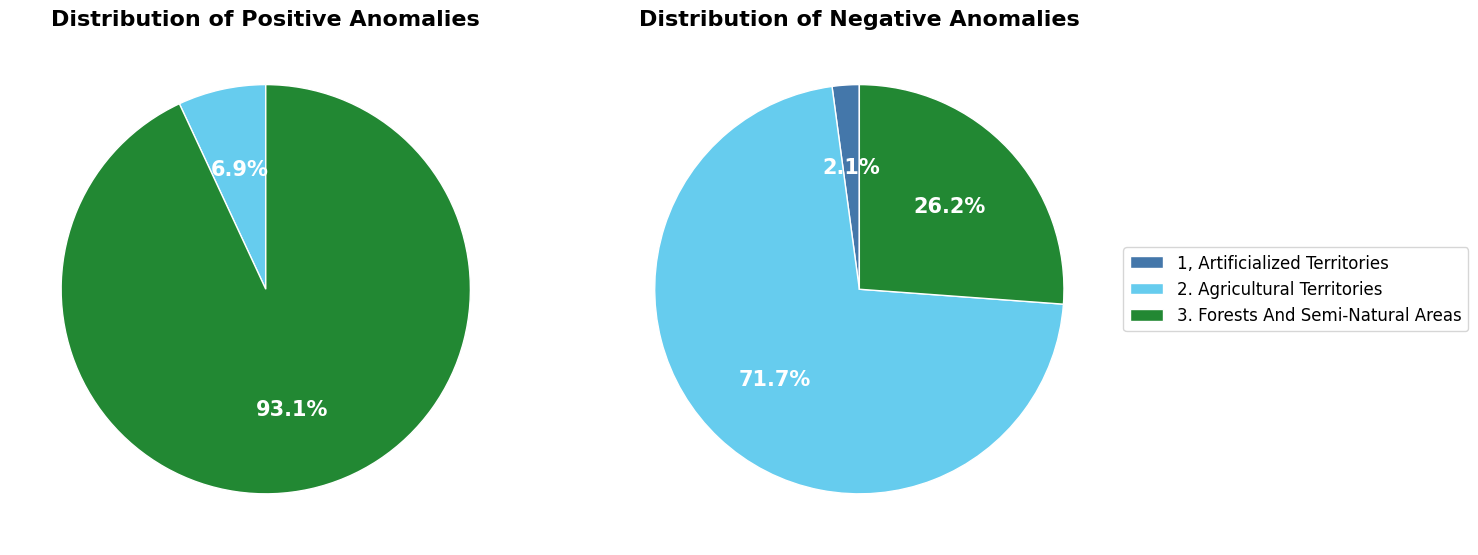

In [ ]:
# plt.figure(figsize=(15,15))
# plt.subplot(3,3,1)
# pos_rel=pos_level1>0
# pos_columns=pos_level1.columns[pos_rel.iloc[0]]
# pos_level1=pos_level1[pos_columns]
# patches, texts, autotexts = plt.pie(pos_level1.iloc[0],
#                                   labels=[''] * len(pos_level1.columns),  # Remove direct labels
#                                   autopct='%1.1f%%',
#                                   colors=['#ff7f0e', '#2ca02c'],
#                                   startangle=90)
# # plt.legend(patches, pos_level1.columns,
# #           title="Categories",
# #           loc="center left",
# #           bbox_to_anchor=(1, 0, 0.5, 1))  # Place legend to the right
# plt.title('Positive anormal points')
# plt.axis('equal')
# plt.subplot(3,1,1)
# patches, texts, autotexts = plt.pie(neg_level1.iloc[0],
#                                   labels=[''] * len(neg_level1.columns),  # Remove direct labels
#                                   autopct='%1.1f%%',
#                                   startangle=90)
# plt.legend(patches, [i[10:] for i in neg_level1.columns],
#           title="Categories",
#           loc="center left",
#           bbox_to_anchor=(0.7, 0, 0.5, 1))  # Place legend to the right
# plt.title('Negative anormal points ')
# plt.axis('equal')
# plt.show()
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Set publication-quality style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 15,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (15, 8),
    'savefig.dpi': 300,
    'savefig.format': 'pdf'
})

# Create figure
fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

# First pie chart (positive anomalies)
ax1 = fig.add_subplot(gs[0])
pos_rel = pos_level1 > 1
pos_columns = pos_level1.columns[pos_rel.iloc[0]]
pos_level1_filtered = pos_level1[pos_columns]

# Professional color palette
colors = ['#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377']

wedges, texts, autotexts = ax1.pie(
    pos_level1_filtered.iloc[0],
    autopct='%1.1f%%',
    colors=colors[1:len(pos_columns)+1],
    startangle=90,
    wedgeprops={'edgecolor': 'w', 'linewidth': 1}
)

# Customize text appearance
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add legend with clean category names
# ax1.legend(
#     wedges,
#     [col.replace('_', ' ').title() for col in pos_columns],
#     title="Positive Anomaly Categories",
#     loc="center left",
#     bbox_to_anchor=(1, 0.5)
# )
ax1.set_title('Distribution of Positive Anomalies', fontweight='bold')

# Second pie chart (negative anomalies)
ax2 = fig.add_subplot(gs[1])
wedges, texts, autotexts = ax2.pie(
    neg_level1.iloc[0],
    autopct='%1.1f%%',
    colors=colors[:len(neg_level1.columns)],
    startangle=90,
    wedgeprops={'edgecolor': 'w', 'linewidth': 1}
)

# Customize text appearance
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Clean up category names by removing prefix
clean_labels = [col[10:].replace('_', ' ').title() if col.startswith('neg_level1')
                else col[10:].replace('_', ' ').title() for col in neg_level1.columns]

ax2.legend(
    wedges,
    clean_labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
ax2.set_title('Distribution of Negative Anomalies', fontweight='bold')

# Add overall figure title
#fig.suptitle('Anomaly Classification Analysis', fontsize=18, fontweight='bold', y=0.98)

# Save figure
plt.savefig('anomaly_classification.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# print("Default color cycle:", default_colors)

In [ ]:
total=pos_level3.iloc[0].sum()
pos_rel=pos_level3/total*100>0
pos_columns=pos_level3.columns[pos_rel.iloc[0]]
pos_level3=pos_level3[pos_columns]
pos_level3=pos_level3[pos_rel]
pos_rel=pos_level3/total*100>0
l=pos_level3/total*100
l.iloc[0].sort_values()

,1
Leyenda_3_1.3.1. Mining extraction zones,0.406504
Leyenda_3_3.3.3. Bare and degraded lands,0.406504
Leyenda_3_2.4.5. Mosaic of crops with natural areas,0.406504
Leyenda_3_2.3.2. Wooded pastures,0.406504
Leyenda_3_3.3.4. Burned areas,0.406504
Leyenda_3_2.2.3. Permanent tree crops,0.406504
Leyenda_3_2.4.2. Mosaic of pastures and crops,0.813008
"Leyenda_3_2.4.3. Mosaic of crops, pastures and natural areas",0.813008
Leyenda_3_2.2.1. Permanent herbaceous crops,0.813008
Leyenda_3_3.3.2. Rock outcrops,0.813008


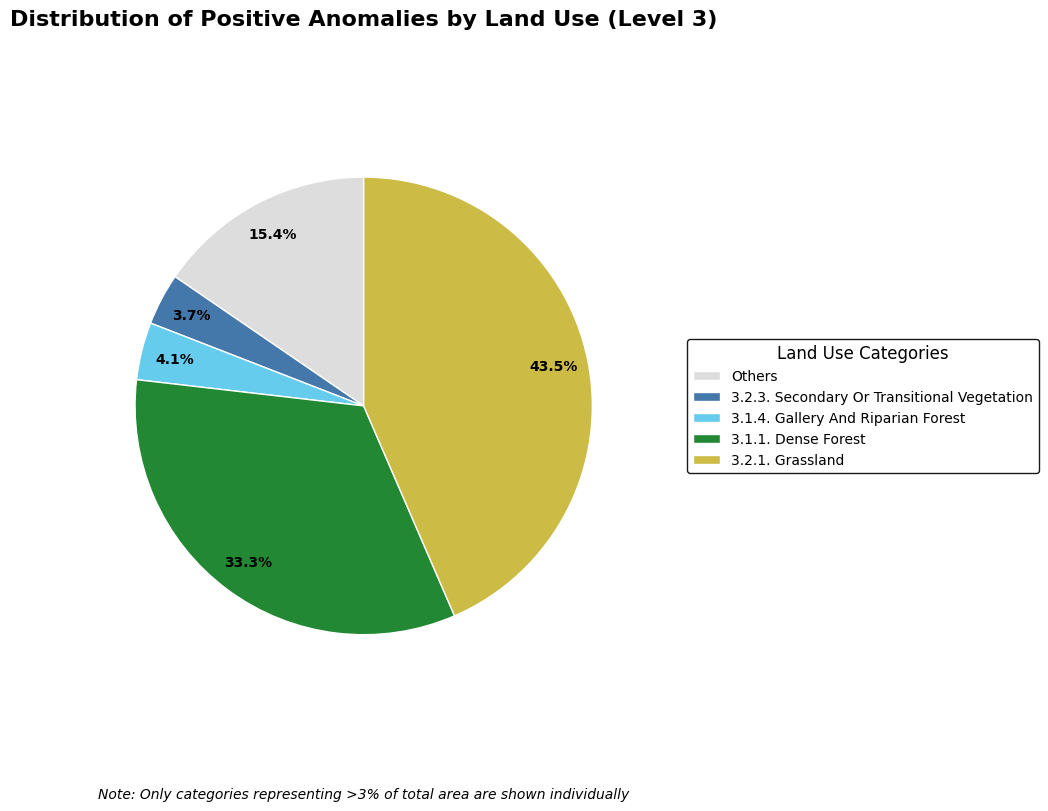

In [ ]:
# pos_rel=pos_level3/total*100>3
# pos_columns=pos_level3.columns[pos_rel.iloc[0]]
# pos_level3=pos_level3[pos_columns]
# pos_level3=pos_level3[pos_rel]
# #neg_level3=neg_level3.sort_values(by=0)
# others=total-pos_level3[pos_rel].iloc[0].sum()
# pos_level3_graph=pos_level3.iloc[0].sort_values().to_numpy()
# index=np.concatenate((np.array(['Others']),np.array([i[10:] for i in pos_level3.iloc[0].sort_values().index])))
# plt.figure(figsize=(10, 8))
# patches, texts, autotexts =plt.pie(np.concatenate((np.array([others]),pos_level3_graph)),  # Get the first (and only) row
#         labels=index,#[''] * len(pos_level3.columns),
#         autopct='%1.1f%%',  # Show percentages
#         startangle=90)
# plt.title('Positive anormal points by land use on level 3  ')
# # plt.legend(patches, pos_level3.iloc[0].sort_values().index,
# #           title="Categories",
# #           loc="center left",
# #           bbox_to_anchor=(1, 0, 0.5, 1))  # Place legend to the right
# plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
# plt.show()

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set publication-quality style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'figure.figsize': (10, 8),
    'savefig.dpi': 300,
    'savefig.format': 'pdf'
})

# Process data
pos_rel = pos_level3/total*100 > 3
pos_columns = pos_level3.columns[pos_rel.iloc[0]]
pos_level3_filtered = pos_level3[pos_columns]
pos_level3_filtered = pos_level3_filtered[pos_rel]

# Calculate "Others" category
others = total - pos_level3_filtered.iloc[0].sum()

# Sort values for better visualization
pos_level3_graph = pos_level3_filtered.iloc[0].sort_values().to_numpy()
index = np.concatenate((np.array(['Others']),
                        np.array([i[10:].replace('_', ' ').title() for i in
                                 pos_level3_filtered.iloc[0].sort_values().index])))

# Set up figure
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

# Color palette - colorblind friendly
colors = ['#DDDDDD', '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377']

# Create pie chart
wedges, texts, autotexts = ax.pie(
    np.concatenate((np.array([others]), pos_level3_graph)),
    labels=None,  # We'll use a legend instead
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(index)],
    wedgeprops={'edgecolor': 'w', 'linewidth': 1},
    pctdistance=0.85
)

# Customize text appearance
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# Add legend with clean category names
ax.legend(
    wedges,
    index,
    title="Land Use Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True,
    framealpha=0.9,
    edgecolor='black'
)

# Add title with proper formatting
ax.set_title('Distribution of Positive Anomalies by Land Use (Level 3)',
             fontweight='bold', pad=20)

# Add footnote for methodology
plt.annotate('Note: Only categories representing >3% of total area are shown individually',
             xy=(0.5, -0.05), xycoords='axes fraction',
             ha='center', va='center', fontsize=10, fontstyle='italic')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

# Save figure
plt.savefig('land_use_anomalies.pdf', bbox_inches='tight')
plt.show()


In [ ]:
total=neg_level3.iloc[0].sum()
neg_rel=neg_level3/total*100>0
neg_columns=neg_level3.columns[neg_rel.iloc[0]]
neg_level3=neg_level3[neg_columns]
neg_level3=neg_level3[neg_rel]
neg_rel=neg_level3/total*100>0
l=neg_level3/total*100
l.iloc[0].sort_values()

,2
Leyenda_3_1.2.2. Road and rail network and associated lands,0.193798
Leyenda_3_3.1.2. Open forest,0.193798
Leyenda_3_2.4.5. Mosaic of crops with natural areas,0.193798
Leyenda_3_2.1.3. Oilseeds and leguminous crops,0.193798
Leyenda_3_2.2.1. Permanent herbaceous crops,0.193798
Leyenda_3_2.2.2. Permanent bush crops,0.193798
Leyenda_3_3.3.4. Burned areas,0.387597
Leyenda_3_3.1.5. Forest plantation,0.387597
Leyenda_3_1.3.1. Mining extraction zones,0.387597
Leyenda_3_1.1.1. Continuous urban fabric,0.581395


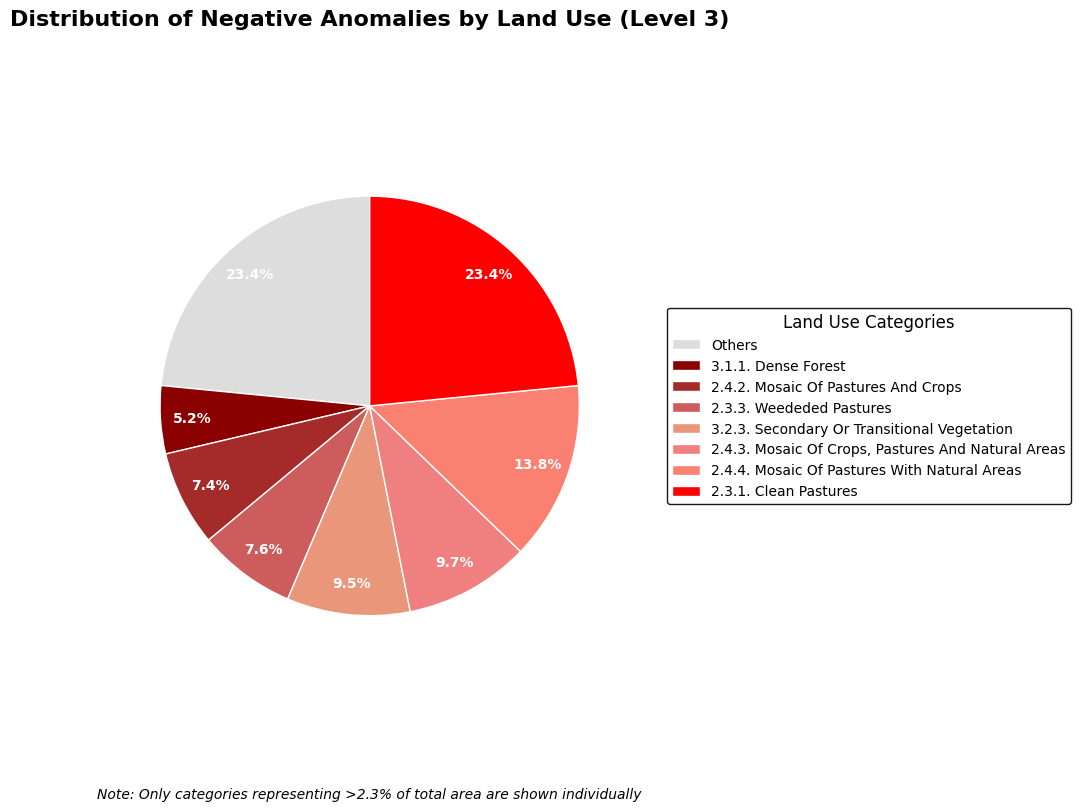

In [ ]:
# neg_rel=neg_level3/total*100>2.3
# neg_columns=neg_level3.columns[neg_rel.iloc[0]]
# neg_level3=neg_level3[neg_columns]
# neg_level3=neg_level3[neg_rel]
# #neg_level3=neg_level3.sort_values(by=0)
# others=total-neg_level3[neg_rel].iloc[0].sum()
# neg_level3_graph=neg_level3.iloc[0].sort_values().to_numpy()
# index=np.concatenate((np.array(['Others']),np.array([i[10:] for i in neg_level3.iloc[0].sort_values().index])))
# plt.figure(figsize=(10, 8))
# patches, texts, autotexts =plt.pie(np.concatenate((np.array([others]),neg_level3_graph)),  # Get the first (and only) row
#         labels=index,#[''] * len(pos_level3.columns),
#         autopct='%1.1f%%',  # Show percentages
#         startangle=90)
# plt.title('Negative anormal points by land use on level 3  ')
# # plt.legend(patches, pos_level3.iloc[0].sort_values().index,
# #           title="Categories",
# #           loc="center left",
# #           bbox_to_anchor=(1, 0, 0.5, 1))  # Place legend to the right
# plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
# plt.show()
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set publication-quality style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'figure.figsize': (10, 8),
    'savefig.dpi': 300,
    'savefig.format': 'pdf'
})

# Process data
neg_rel = neg_level3/total*100 > 4
neg_columns = neg_level3.columns[neg_rel.iloc[0]]
neg_level3_filtered = neg_level3[neg_columns]
neg_level3_filtered = neg_level3_filtered[neg_rel]

# Calculate "Others" category
others = total - neg_level3_filtered.iloc[0].sum()

# Sort values for better visualization
neg_level3_graph = neg_level3_filtered.iloc[0].sort_values().to_numpy()
index = np.concatenate((np.array(['Others']),
                        np.array([i[10:].replace('_', ' ').title() for i in
                                  neg_level3_filtered.iloc[0].sort_values().index])))

# Set up figure
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

# Color palette - use reds for negative anomalies (diverging from blue in positive chart)
colors = ['#DDDDDD', '#8B0000', '#A52A2A', '#CD5C5C', '#E9967A', '#F08080', '#FA8072', '#FF0000']  # Added Pure Red

# Create pie chart
wedges, texts, autotexts = ax.pie(
    np.concatenate((np.array([others]), neg_level3_graph)),
    labels=None,  # We'll use a legend instead
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(index)],
    wedgeprops={'edgecolor': 'w', 'linewidth': 1},
    pctdistance=0.85
)

# Customize text appearance
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# Add legend with clean category names
ax.legend(
    wedges,
    index,
    title="Land Use Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True,
    framealpha=0.9,
    edgecolor='black'
)

# Add title with proper formatting
ax.set_title('Distribution of Negative Anomalies by Land Use (Level 3)',
             fontweight='bold', pad=20)

# Add footnote for methodology
plt.annotate('Note: Only categories representing >2.3% of total area are shown individually',
             xy=(0.5, -0.05), xycoords='axes fraction',
             ha='center', va='center', fontsize=10, fontstyle='italic')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

# Save figure
plt.savefig('negative_land_use_anomalies.pdf', bbox_inches='tight')
plt.show()

# Suplemental
Se debe correr la sección alistamiento de datos hastala línea donde se carga df_s y se muestra un mapa

In [ ]:
encoded_df45=encoded_df[(encoded_df['Leyenda_1_4. Áreas húmedas']>0)+(encoded_df['Leyenda_1_5. Superficies de agua']>0)]#tabla para eliminar el glint en la plataforma continental

In [ ]:
encoded_df45

,OBJECTID,codigo,leyenda,insumo,apoyo,confiabili,cambio,nivel_1,nivel_2,nivel_3,...,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua,groupb
217,218.0,512,"5.1.2. Lagunas, lagos y ciénagas naturales",Landsat_2020_mediana_07042021,None,SI,1,5,51,512,...,False,False,False,False,False,False,False,False,True,0
249,250.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,None,SI,1,4,41,411,...,False,False,False,False,False,False,False,True,False,0
255,256.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,None,SI,1,4,41,411,...,False,False,False,False,False,False,False,True,False,0
269,270.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,None,SI,2,4,41,411,...,False,False,False,False,False,False,False,True,False,0
338,339.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,None,SI,1,4,41,411,...,False,False,False,False,False,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393434,393435.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,False,False,False,False,False,False,False,True,False,0
393435,393436.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,False,False,False,False,False,False,False,True,False,0
393450,393451.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,False,False,False,False,False,False,False,True,False,0
393453,393454.0,511,5.1.1. Ríos,Landsat_2020_mediana_07042021,None,SI,1,5,51,511,...,False,False,False,False,False,False,False,False,True,0


,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-77.305,7.745,1.606068e+12,1866.559650
1,-77.305,7.755,1.606068e+12,1866.559615
2,-77.295,7.705,1.606068e+12,1866.559567
3,-77.295,7.715,1.606068e+12,1866.559602
4,-77.295,7.725,1.606068e+12,1866.559608
...,...,...,...,...
307150,-67.325,3.455,1.577987e+12,1835.456421
307151,-67.315,3.375,1.580923e+12,1851.070163
307152,-67.315,3.385,1.580923e+12,1851.070189
307153,-67.315,3.435,1.577987e+12,1835.456439


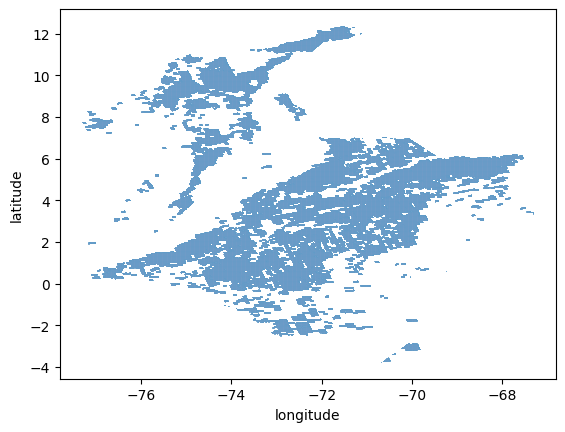

In [ ]:
#df_g es el promedio de todos los año filtrado sin cuerpo de agua para evitar el glint
#df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom.csv')
df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020.csv')
#df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020
#df_g=df_s[df_s['Leyenda_1_4. Áreas húmedas'].isnull()+df_s['Leyenda_1_5. Superficies de agua'].isnull()]#.plot(x='longitude',y='latitude',column='CH4_column_volume_mixing_ratio_dry_air_bias_corrected')
#sns.scatterplot(data=df_g,x='longitude',y='latitude',s=0.5)#,hue='CH4_column_volume_mixing_ratio_dry_air_bias_corrected')
#df_g.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/glint_intersect_filtered.csv')
#df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/corr_land_2020.csv')
#df_g=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/glint_intersect_filtered.csv')
sns.scatterplot(data=df_s,x='longitude',y='latitude',s=0.5)
df_s

In [ ]:
df_s['coordinate_x']=df_s['longitude'].apply(lambda x: [x])
df_s['coordinate_y']=df_s['latitude'].apply(lambda x: [x])
df_s['coordinates']=df_s['coordinate_x']+df_s['coordinate_y']
delta_y=0.01
delta_x=0.01
df_s['geometry'] = df_s['coordinates'].apply(
    lambda x: Polygon([
        (x[0] - delta_x, x[1] - delta_y),
        (x[0] - delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] - delta_y)
    ]))# Corregir el delta
df_s

,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry
0,-77.305,7.745,1.606068e+12,1866.559650,[-77.305],[7.745],"[-77.305, 7.745]","POLYGON ((-77.31500000000001 7.735, -77.315000..."
1,-77.305,7.755,1.606068e+12,1866.559615,[-77.305],[7.755],"[-77.305, 7.755]","POLYGON ((-77.31500000000001 7.745, -77.315000..."
2,-77.295,7.705,1.606068e+12,1866.559567,[-77.295],[7.705],"[-77.295, 7.705]","POLYGON ((-77.305 7.695, -77.305 7.715, -77.28..."
3,-77.295,7.715,1.606068e+12,1866.559602,[-77.295],[7.715],"[-77.295, 7.715]","POLYGON ((-77.305 7.705, -77.305 7.725, -77.28..."
4,-77.295,7.725,1.606068e+12,1866.559608,[-77.295],[7.725],"[-77.295, 7.725]","POLYGON ((-77.305 7.715, -77.305 7.73499999999..."
...,...,...,...,...,...,...,...,...
307150,-67.325,3.455,1.577987e+12,1835.456421,[-67.325],[3.455],"[-67.325, 3.455]",POLYGON ((-67.33500000000001 3.445000000000000...
307151,-67.315,3.375,1.580923e+12,1851.070163,[-67.315],[3.375],"[-67.315, 3.375]","POLYGON ((-67.325 3.365, -67.325 3.385, -67.30..."
307152,-67.315,3.385,1.580923e+12,1851.070189,[-67.315],[3.385],"[-67.315, 3.385]","POLYGON ((-67.325 3.375, -67.325 3.39499999999..."
307153,-67.315,3.435,1.577987e+12,1835.456439,[-67.315],[3.435],"[-67.315, 3.435]","POLYGON ((-67.325 3.4250000000000003, -67.325 ..."


In [ ]:
l_in=list(encoded_df45.columns)
while not l_in[0]=='Leyenda_3_1.1.1. Tejido urbano continuo':
    l_in.pop(0)#(list(dfg.columns))
l_in.remove('groupb')
for i in l_in:
    encoded_df45[i]=encoded_df[i]*encoded_df['SHAPE_Area']
#df_s.loc[:,l_in]=None
#df_s['Leyenda_1_4. Áreas húmedas'][0]

/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
#df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered_pausa_349827.csv')


In [ ]:
# for j in df_s.index:
#     #print(j)
#     f=encoded_df45[df_s['geometry'][j].intersects(encoded_df45['geometry'])]
#     f1=f.groupby('groupb')[l_in].aggregate('sum') # Se suma el área total intersectada
#     if not len(f1)==0:
#       for i in l_in:
#         df_s.loc[j, i]=f1[i].iloc[0].copy()
#     if j%5e4==0:
#       print(j)
listind=[]
for j in encoded_df45.index:
    f=df_s[encoded_df45['geometry'][j].intersects(df_s['geometry'])]
    #f1=f.groupby('groupb')[l_in].aggregate('sum') # Se suma el área total intersectada
    #listind.append(f.index)
    df_s.drop(f.index,inplace=True)
    #

#df_sfil=df_s[~listind]
df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered.csv')
#correr hasta acá

In [ ]:
# listindc=listind[0]
# for i in range(1,len(listind)):
#   #listindc=listindc.append(listind[i])
#   try:
#     df_s.drop(listind[i],inplace=True)
#   except: KeyError
df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered.csv')

<Axes: xlabel='longitude', ylabel='latitude'>

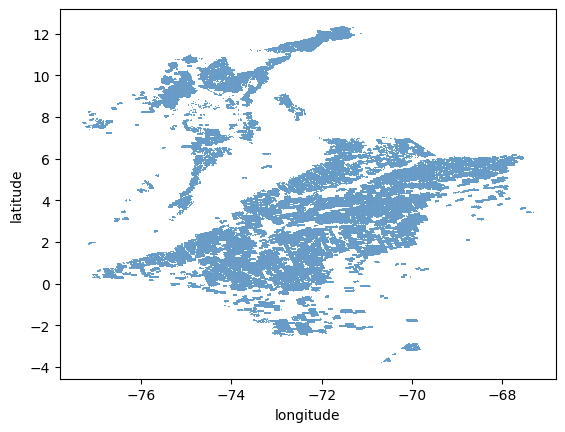

In [ ]:
sns.scatterplot(data=df_s,x='longitude',y='latitude',s=0.5)

,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-77.305,7.745,1.606068e+12,1866.559650
1,-77.305,7.755,1.606068e+12,1866.559615
2,-77.295,7.705,1.606068e+12,1866.559567
3,-77.295,7.715,1.606068e+12,1866.559602
4,-77.295,7.725,1.606068e+12,1866.559608
...,...,...,...,...
307132,-67.365,3.445,1.577987e+12,1835.456421
307135,-67.355,3.435,1.577987e+12,1835.456433
307150,-67.325,3.455,1.577987e+12,1835.456421
307153,-67.315,3.435,1.577987e+12,1835.456439


In [ ]:
df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered.csv')


In [ ]:
df_g=df_s[df_s['Leyenda_1_5. Superficies de agua'].isnull()+df_s['Leyenda_1_5. Superficies de agua'].isnull()]

<Axes: xlabel='longitude', ylabel='latitude'>

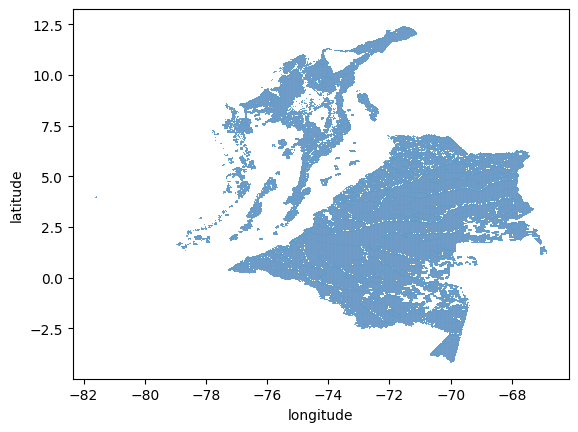

In [ ]:
sns.scatterplot(data=df_g,x='longitude',y='latitude',s=0.5)#,hue='label',s=1,palette=sns.color_palette("tab10"))

In [ ]:
df_g.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_filtered.csv')

In [ ]:
df_g.dtypes.head(60)

,0
Unnamed: 0.1,int64
Unnamed: 0,int64
latitude,float64
longitude,float64
time,float64
CH4_column_volume_mixing_ratio_dry_air_bias_corrected,float64
coordinate_x,object
coordinate_y,object
coordinates,object
geometry,object


In [ ]:
#Correr desde acá 11/11/24
df_g=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_filtered.csv')
df_g['coordinate_x']=df_g['longitude'].apply(lambda x: [x])
df_g['coordinate_y']=df_g['latitude'].apply(lambda x: [x])
df_g['coordinates']=df_g['coordinate_x']+df_g['coordinate_y']
df_g
df_g.coordinates

,coordinates
0,"[-69.995, -4.165]"
1,"[-70.005, -4.155]"
2,"[-69.965, -4.135]"
3,"[-69.955, -4.135]"
4,"[-69.94500000000001, -4.135]"
...,...
494249,"[-71.58500000000001, 12.415]"
494250,"[-71.575, 12.415]"
494251,"[-71.605, 12.425]"
494252,"[-71.595, 12.425]"


In [ ]:
df_completo=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_corrected.csv')
df_completo

,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date
0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12
1,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
2,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
3,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
4,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
...,...,...,...,...,...,...
9121505,20241102T171753_20241104T094950,-72.435,4.525,1730569168000,1930.100098,2024-11-02 12:39:28
9121506,20241102T171753_20241104T094950,-72.445,4.525,1730569168000,1930.060781,2024-11-02 12:39:28
9121507,20241102T171753_20241104T094950,-72.455,4.525,1730569168000,1929.658248,2024-11-02 12:39:28
9121508,20241102T171753_20241104T094950,-72.255,4.525,1730569168000,1939.287932,2024-11-02 12:39:28


In [ ]:
df_completo['coordinate_x']=df_completo['longitude'].apply(lambda x: [x])
df_completo['coordinate_y']=df_completo['latitude'].apply(lambda x: [x])
df_completo['coordinates']=df_completo['coordinate_x']+df_completo['coordinate_y']
df_completo

,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates
0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]"
1,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]"
2,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]"
3,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]"
4,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]"
...,...,...,...,...,...,...,...,...,...
9121505,20241102T171753_20241104T094950,-72.435,4.525,1730569168000,1930.100098,2024-11-02 12:39:28,[-72.435],[4.525],"[-72.435, 4.525]"
9121506,20241102T171753_20241104T094950,-72.445,4.525,1730569168000,1930.060781,2024-11-02 12:39:28,[-72.44500000000001],[4.525],"[-72.44500000000001, 4.525]"
9121507,20241102T171753_20241104T094950,-72.455,4.525,1730569168000,1929.658248,2024-11-02 12:39:28,[-72.455],[4.525],"[-72.455, 4.525]"
9121508,20241102T171753_20241104T094950,-72.255,4.525,1730569168000,1939.287932,2024-11-02 12:39:28,[-72.255],[4.525],"[-72.255, 4.525]"


In [ ]:
#df_completo.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/colombia_results.csv')
# df_completo=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/colombia_results.csv')
# df_completo

KeyboardInterrupt: 

In [ ]:
#df_completo.coordinates.to_numpy()[0]
df_completo_ng=df_completo[df_completo.coordinates.isin(df_g.coordinates)]#Se filtran los datos para saber cuáles son los válidos sin glint
df_completo_ng


In [ ]:
df_completo_ng.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_filtered.csv')

In [ ]:
#df_completo_ng.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_filtered.csv')
#df_completo.coordinates.isin(df_g.coordinates)

In [ ]:
df_completo_ng.dtypes

,0
id,object
longitude,float64
latitude,float64
time,int64
CH4_column_volume_mixing_ratio_dry_air_bias_corrected,float64
date,object
coordinate_x,object
coordinate_y,object
coordinates,object


In [ ]:
df_completo_ng=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_corrected.csv')
df_completo_ng['date']=pd.to_datetime(df_completo_ng['date'])
#df_comleto_ng['year']=df_completo_ng['date'].dt.year
df_2020=df_completo_ng[df_completo_ng.date.dt.year==2020]
df_2020.groupby(['longitude','latitude']).mean('CH4_column_volume_mixing_ratio_dry_air_bias_corrected').to_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered.csv')

In [ ]:
df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020.csv')
df_s

,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-77.305,7.745,1.606068e+12,1866.559650
1,-77.305,7.755,1.606068e+12,1866.559615
2,-77.295,7.705,1.606068e+12,1866.559567
3,-77.295,7.715,1.606068e+12,1866.559602
4,-77.295,7.725,1.606068e+12,1866.559608
...,...,...,...,...
307150,-67.325,3.455,1.577987e+12,1835.456421
307151,-67.315,3.375,1.580923e+12,1851.070163
307152,-67.315,3.385,1.580923e+12,1851.070189
307153,-67.315,3.435,1.577987e+12,1835.456439


In [ ]:
#df_s[(df_s['longitude']==-71.495)*(df_s['latitude']==11.925)].index
df_s['geometry'][0].intersects(encoded_df45['geometry'])

,geometry
217,False
249,False
255,False
269,False
338,False
...,...
393434,False
393435,False
393450,False
393453,False


In [ ]:
encoded_df45['geometry'][217].intersects(df_s['geometry'])

NameError: name 'encoded_df45' is not defined